# 🏠 Pipeline Completo de ML — **Regressão**
### Pós-Graduação em Ciência de Dados | Melhores Práticas End-to-End
**Dataset:** California Housing (StatLib / Scikit-learn) | **Tarefa:** Prever o valor mediano de imóveis

---
> **Como usar:** Execute as células em ordem. Tempo estimado: **~10–15 minutos**.

| Etapa | Conteúdo |
|-------|----------|
| 1 | EDA — distribuições, geoespacial, correlações, outliers |
| 2 | Feature Engineering — novas features, capping, log transform |
| 3 | Seleção de Features — Boruta |
| 4 | Modelo Baseline — DummyRegressor + Ridge |
| 5 | Modelos SOTA — RF, XGBoost, LightGBM, CatBoost |
| 6 | Métricas — RMSE, MAE, R² |
| 7 | Tunagem — Optuna + CatBoost |
| 8 | Diagnóstico — Resíduos e Overfitting |
| 9 | Interpretabilidade — SHAP Global + Local |


## ⚙️ Célula 0 — Instalação

In [1]:
!pip install -q boruta shap optuna lightgbm catboost xgboost
print("Instalacao concluida!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00
Instalacao concluida!


## 📦 Célula 1 — Imports

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import seaborn as sns
from scipy import stats
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

print("Todas as bibliotecas importadas!")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Optuna {optuna.__version__}")


Todas as bibliotecas importadas!
NumPy 2.0.2 | Pandas 2.2.2 | Optuna 4.8.0


---
## 📌 Etapa 1 — Análise Exploratória de Dados (EDA)

> O California Housing Dataset é derivado do Censo dos EUA de 1990.  
> Contém ~20.000 blocos censitários da Califórnia com desafios reais:  
> outliers, distribuições assimétricas e forte dependência espacial.

**Features:**
| Feature | Descrição |
|---------|-----------|
| MedInc | Renda mediana do bloco ($10k) |
| HouseAge | Idade mediana das casas |
| AveRooms | Média de cômodos por domicílio |
| AveBedrms | Média de quartos por domicílio |
| Population | Moradores no bloco |
| AveOccup | Moradores médios por domicílio |
| Latitude | Latitude do centróide |
| Longitude | Longitude do centróide |
| **MedHouseVal** | **TARGET — Valor mediano ($100k)** |


In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
TARGET = 'MedHouseVal'

print(f"Shape: {df.shape}")
print(f"Target: {TARGET} (valor mediano em $100.000)")
df.head()


Shape: (20640, 9)
Target: MedHouseVal (valor mediano em $100.000)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Estatísticas descritivas enriquecidas
desc = df.describe().T
desc['CV%']      = (desc['std'] / desc['mean'] * 100).round(1)
desc['Skewness'] = df.skew().round(3)
desc.round(3)


,count,mean,std,min,25%,50%,75%,max,CV%,Skewness
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000,49.1,1.647
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000,43.9,0.060
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909,45.6,20.698
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067,43.2,31.317
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000,79.4,4.936
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333,338.2,97.640
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950,6.0,0.466
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310,-1.7,-0.298
MedHouseVal,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000,55.8,0.978


In [5]:
# Valores ausentes
missing = df.isnull().sum()
missing_df = pd.DataFrame({'Qtd': missing, '%': (missing/len(df)*100).round(2)})
missing_df = missing_df[missing_df['Qtd'] > 0]

if missing_df.empty:
    print("Nenhum valor ausente encontrado neste dataset.")
    print("")
    print("Nota: Em datasets reais voce encontrara valores ausentes.")
    print("Estrategias: imputacao por mediana, KNN Imputer, ou modelos")
    print("que tratam nativamente (LightGBM, CatBoost).")
else:
    print(missing_df)


Nenhum valor ausente encontrado neste dataset.

Nota: Em datasets reais voce encontrara valores ausentes.
Estrategias: imputacao por mediana, KNN Imputer, ou modelos
que tratam nativamente (LightGBM, CatBoost).


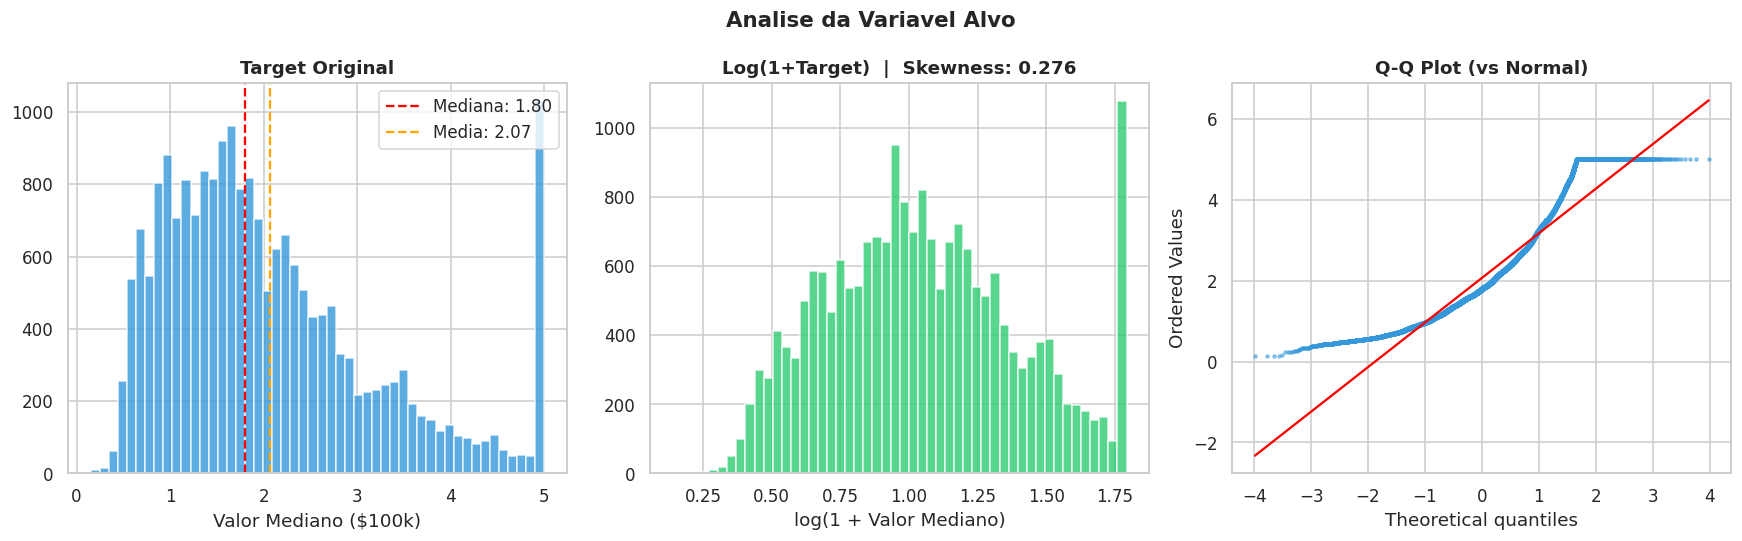

Minimo : $15
Mediana: $180
Maximo : $500
Skew   : 0.978

ATENCAO: O target e cortado em $500,001 (valor 5.0 no dataset).
Isso cria um 'teto' artificial que pode afetar predicoes.


In [6]:
# ============================================================
# ANALISE DO TARGET
#
# Em regressao, a distribuicao do target importa!
# Distribuicoes assimétricas podem exigir transformacao log.
# Modelos de arvore sao mais robustos a isso do que modelos lineares.
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma original
axes[0].hist(df[TARGET], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df[TARGET].median(), color='red',    linestyle='--',
                label=f'Mediana: {df[TARGET].median():.2f}')
axes[0].axvline(df[TARGET].mean(),   color='orange', linestyle='--',
                label=f'Media: {df[TARGET].mean():.2f}')
axes[0].set_title('Target Original', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Mediano ($100k)')
axes[0].legend()

# Log transform
log_t = np.log1p(df[TARGET])
axes[1].hist(log_t, bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Log(1+Target)  |  Skewness: {log_t.skew():.3f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Valor Mediano)')

# Q-Q Plot
stats.probplot(df[TARGET], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (vs Normal)', fontsize=12, fontweight='bold')
axes[2].get_lines()[0].set(color='#3498db', markersize=2, alpha=0.5)
axes[2].get_lines()[1].set(color='red')

plt.suptitle('Analise da Variavel Alvo', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Minimo : ${df[TARGET].min()*100:,.0f}")
print(f"Mediana: ${df[TARGET].median()*100:,.0f}")
print(f"Maximo : ${df[TARGET].max()*100:,.0f}")
print(f"Skew   : {df[TARGET].skew():.3f}")
print("")
print("ATENCAO: O target e cortado em $500,001 (valor 5.0 no dataset).")
print("Isso cria um 'teto' artificial que pode afetar predicoes.")


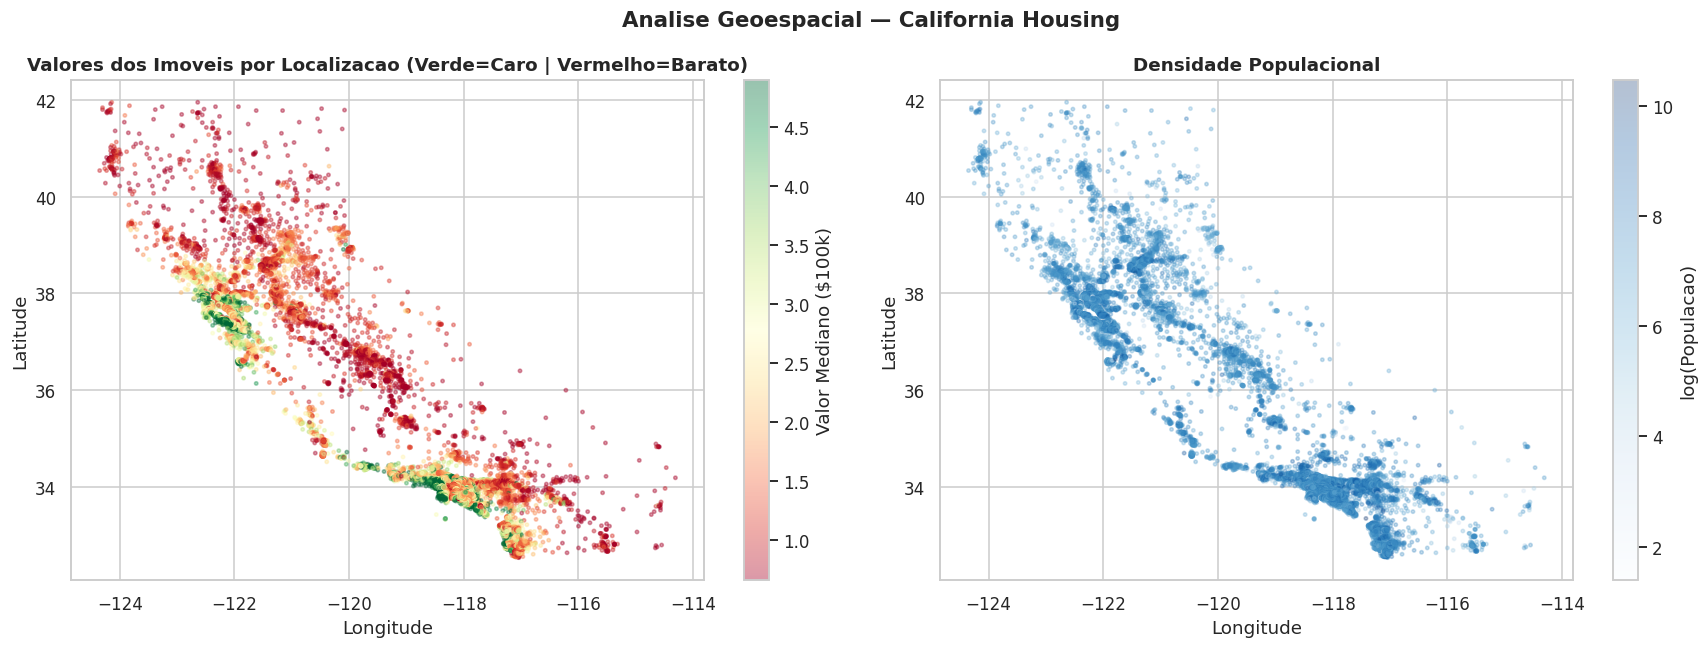

Observacoes:
  San Francisco (lat~37.8, lon~-122.4): imoveis mais caros
  Los Angeles   (lat~34.0, lon~-118.2): alta concentracao cara
  Interior da California              : imoveis mais baratos
  → Latitude e Longitude serao features muito importantes!


In [8]:
# ============================================================
# ANALISE GEOESPACIAL
#
# California Housing tem coordenadas geograficas!
# A localizacao e frequentemente o fator DOMINANTE no preco
# de imoveis — o mapa revela isso claramente.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(df['Longitude'], df['Latitude'],
    c=df[TARGET], cmap='RdYlGn', alpha=0.4, s=5,
    vmin=df[TARGET].quantile(0.05), vmax=df[TARGET].quantile(0.95))
plt.colorbar(sc1, ax=axes[0], label='Valor Mediano ($100k)')
axes[0].set_title('Valores dos Imoveis por Localizacao (Verde=Caro | Vermelho=Barato)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

sc2 = axes[1].scatter(df['Longitude'], df['Latitude'],
    c=np.log1p(df['Population']), cmap='Blues', alpha=0.3, s=5)
plt.colorbar(sc2, ax=axes[1], label='log(Populacao)')
axes[1].set_title('Densidade Populacional', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

plt.suptitle('Analise Geoespacial — California Housing', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Observacoes:")
print("  San Francisco (lat~37.8, lon~-122.4): imoveis mais caros")
print("  Los Angeles   (lat~34.0, lon~-118.2): alta concentracao cara")
print("  Interior da California              : imoveis mais baratos")
print("  → Latitude e Longitude serao features muito importantes!")


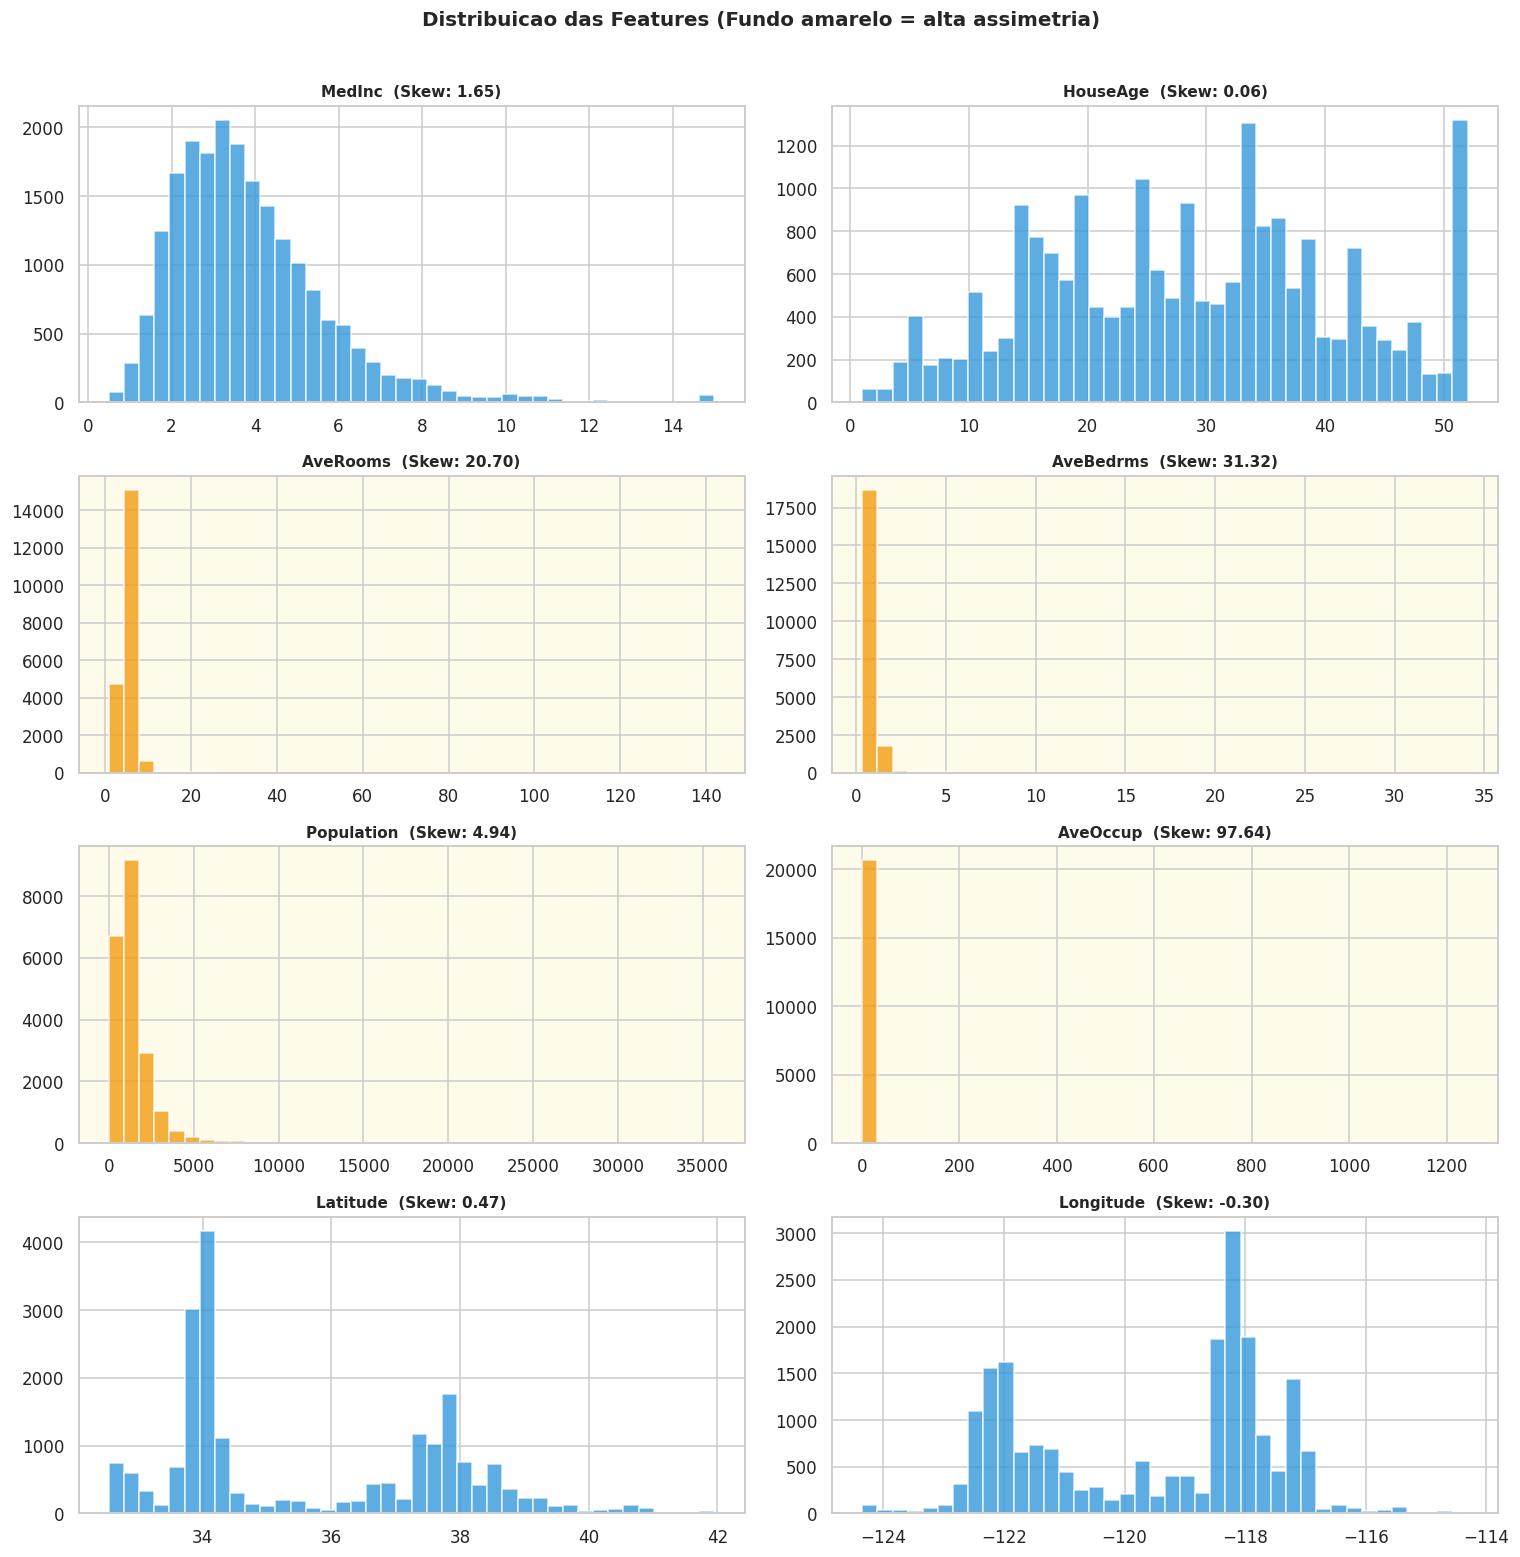

In [10]:
# ============================================================
# DISTRIBUICOES DAS FEATURES
# Destaque para features com alta assimetria (fundo amarelo)
# ============================================================
feature_cols = [c for c in df.columns if c != TARGET]
n_cols, n_rows = 2, (len(feature_cols)+1)//2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*3.5))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    skew = df[feat].skew()
    color = '#f39c12' if abs(skew) > 2 else '#3498db'
    if abs(skew) > 2: axes[i].set_facecolor('#fffbea')
    axes[i].hist(df[feat], bins=40, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feat}  (Skew: {skew:.2f})', fontsize=10, fontweight='bold')

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribuicao das Features (Fundo amarelo = alta assimetria)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


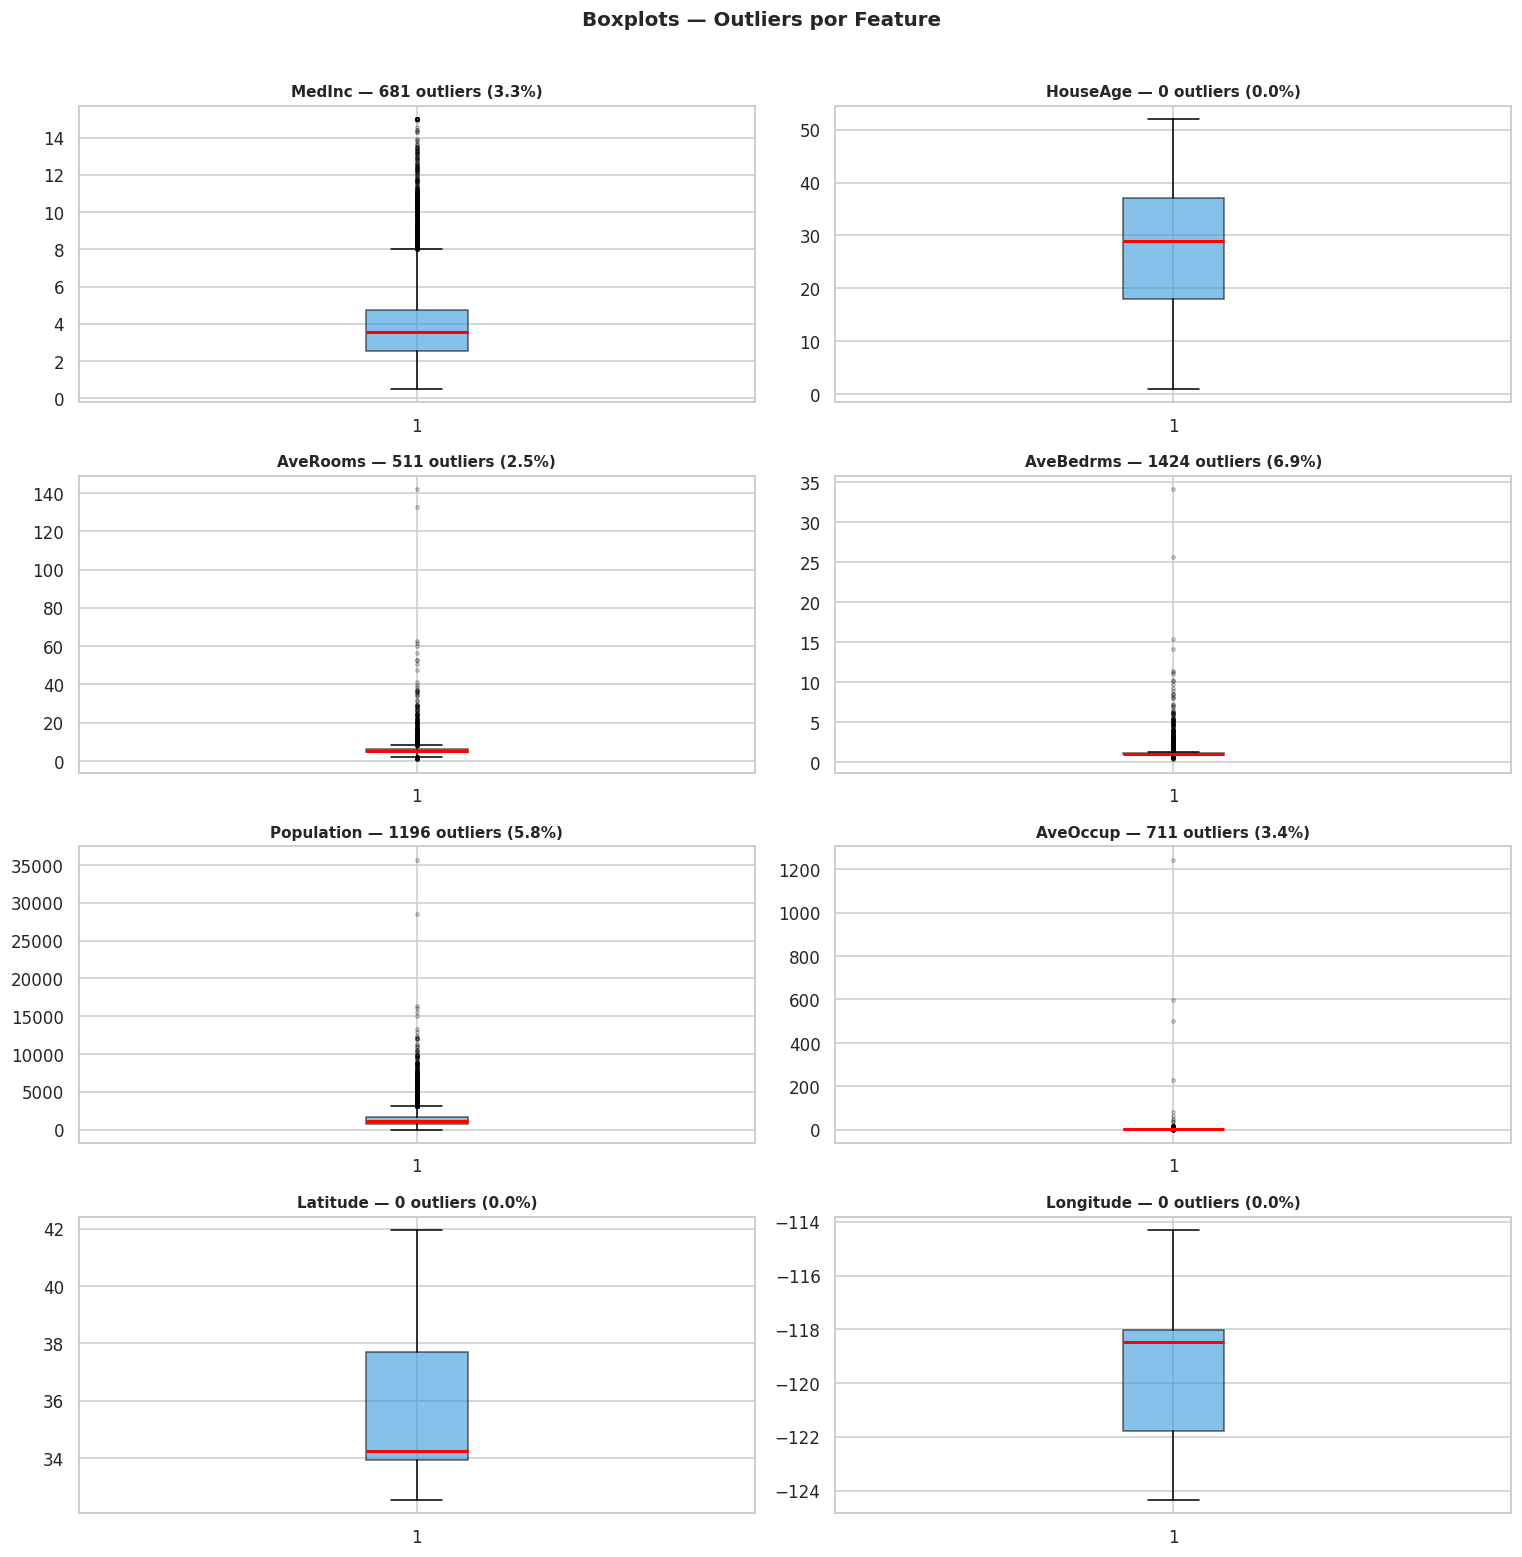

Resumo de outliers:
AveBedrms     1424
Population    1196
AveOccup       711
MedInc         681
AveRooms       511
HouseAge         0
Latitude         0
Longitude        0


In [11]:
# ============================================================
# DETECCAO DE OUTLIERS — METODO IQR
# ============================================================
n_rows_box = (len(feature_cols)+1)//2
fig, axes = plt.subplots(n_rows_box, 2, figsize=(14, n_rows_box*3.5))
axes = axes.flatten()

outlier_info = {}
for i, feat in enumerate(feature_cols):
    axes[i].boxplot(df[feat], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1-1.5*IQR)|(df[feat] > Q3+1.5*IQR)).sum()
    outlier_info[feat] = n_out
    axes[i].set_title(f'{feat} — {n_out} outliers ({n_out/len(df)*100:.1f}%)',
                      fontsize=10, fontweight='bold')

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplots — Outliers por Feature', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Resumo de outliers:")
print(pd.Series(outlier_info).sort_values(ascending=False).to_string())


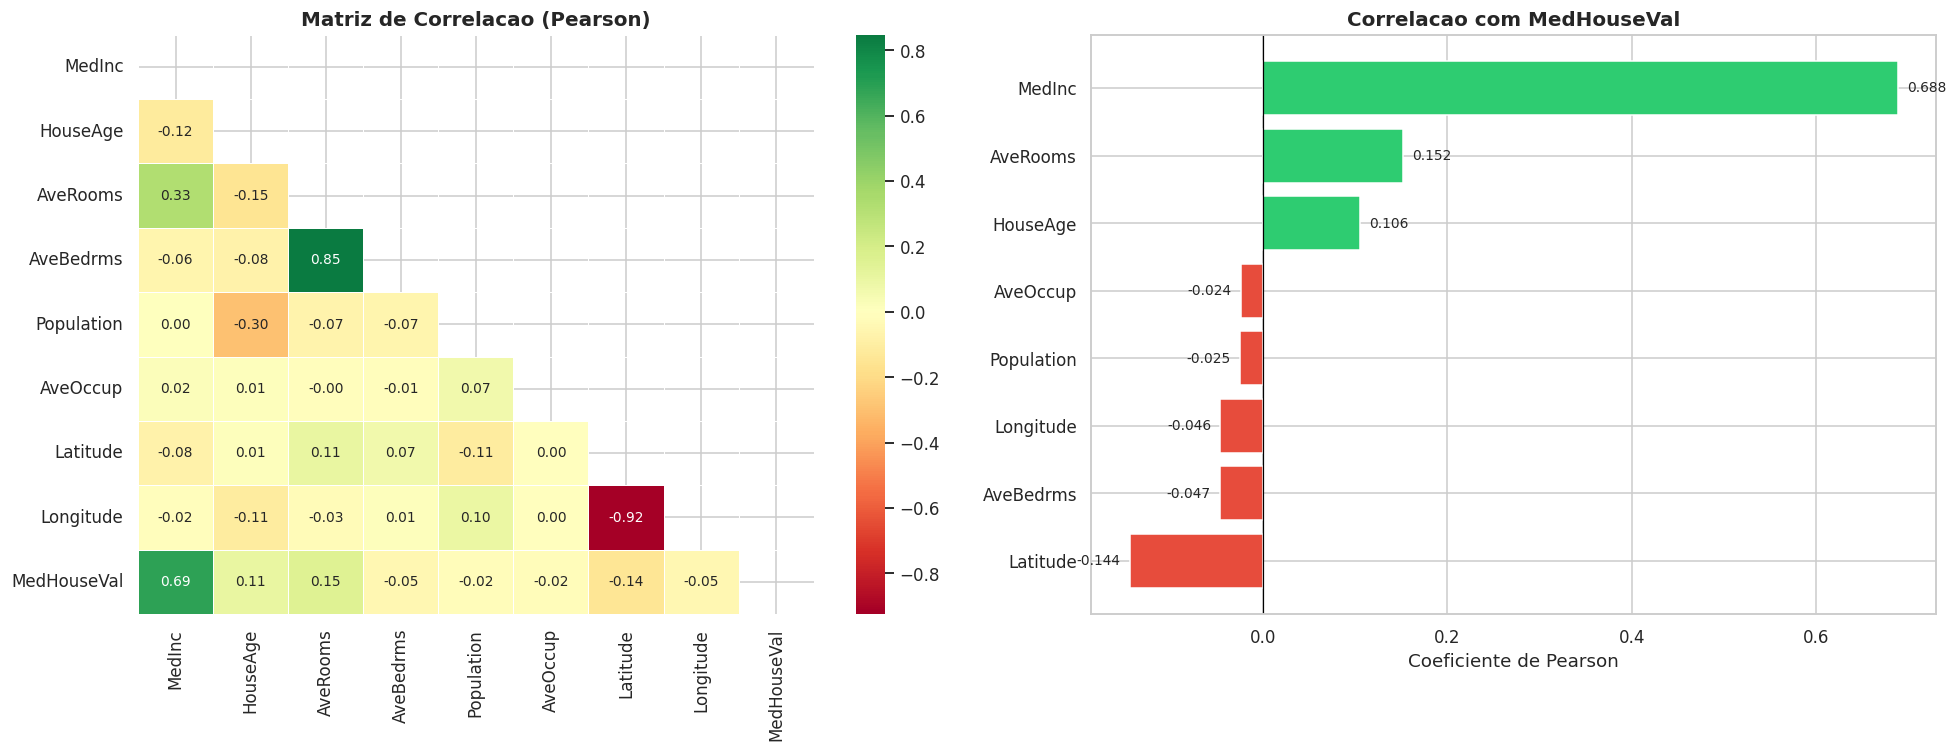

Feature mais correlacionada com o target: MedInc
Coeficiente: 0.6881

ATENCAO: AveRooms e AveBedrms sao altamente correlacionadas
(multicolinearidade) - Boruta ajuda a lidar com isso.


In [12]:
# ============================================================
# ANALISE DE CORRELACAO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt=".2f",
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={"size": 9})
axes[0].set_title('Matriz de Correlacao (Pearson)', fontsize=13, fontweight='bold')

target_corr = corr[TARGET].drop(TARGET).sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title(f'Correlacao com {TARGET}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coeficiente de Pearson')
for val, feat in zip(target_corr.values, target_corr.index):
    axes[1].text(val+(0.01 if val>=0 else -0.01), feat, f'{val:.3f}',
                 va='center', ha='left' if val>=0 else 'right', fontsize=9)

plt.tight_layout(); plt.show()

print(f"Feature mais correlacionada com o target: {target_corr.abs().idxmax()}")
print(f"Coeficiente: {target_corr.abs().max():.4f}")
print("")
print("ATENCAO: AveRooms e AveBedrms sao altamente correlacionadas")
print("(multicolinearidade) - Boruta ajuda a lidar com isso.")


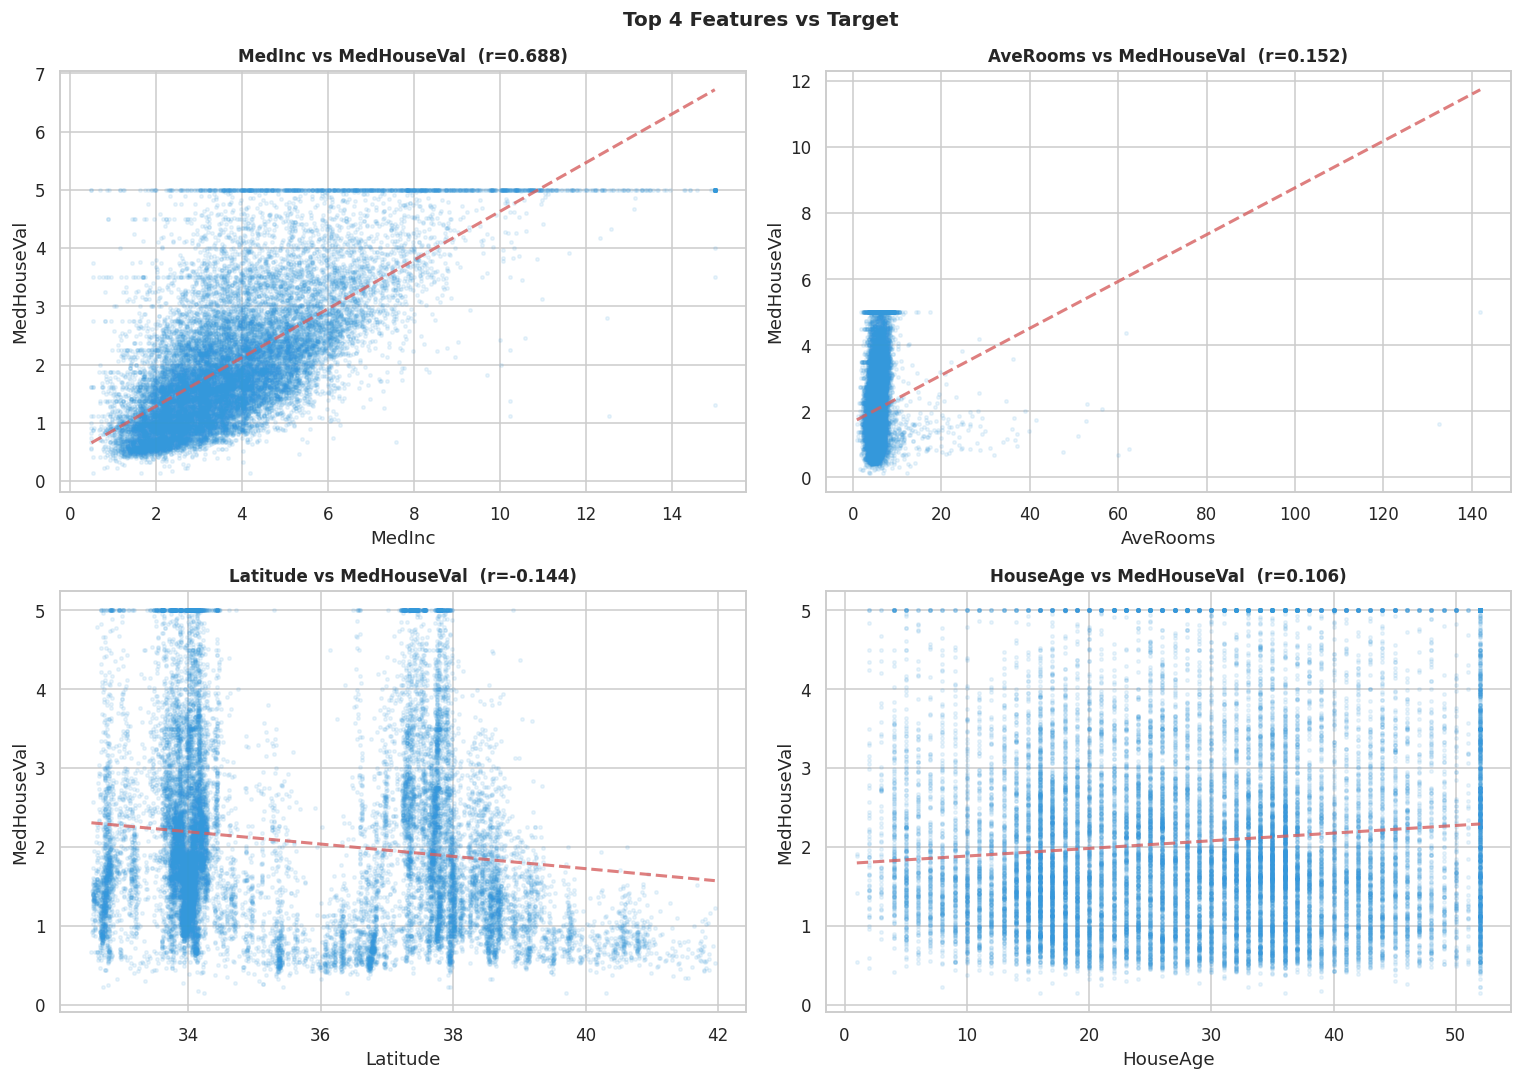

In [13]:
# ============================================================
# SCATTER PLOTS: TOP FEATURES vs TARGET
# ============================================================
top_feats = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    axes[i].scatter(df[feat], df[TARGET], alpha=0.1, s=5, color='#3498db')
    z = np.polyfit(df[feat], df[TARGET], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), "r--", lw=2, alpha=0.8)
    r = df[feat].corr(df[TARGET])
    axes[i].set_title(f'{feat} vs {TARGET}  (r={r:.3f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feat); axes[i].set_ylabel(TARGET)

plt.suptitle('Top 4 Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## ⚙️ Etapa 2 — Feature Engineering

> **Regra de ouro:** Features criadas com conhecimento de domínio  
> frequentemente superam horas de tunagem de hiperparâmetros.  
> Aqui criamos 8 novas features baseadas em conhecimento imobiliário e demográfico.


In [14]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print(f"Features originais ({X.shape[1]}): {X.columns.tolist()}")


Features originais (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [15]:
# ============================================================
# CRIACAO DE NOVAS FEATURES — Conhecimento de Dominio Imobiliario
# ============================================================
X_eng = X.copy()

# 1. Quartos por cômodo — indicador de qualidade do imovel
X_eng['rooms_per_household'] = X['AveRooms'] / X['AveOccup']

# 2. Razao quartos/total de comodos — tamanho relativo
X_eng['bedrooms_ratio'] = X['AveBedrms'] / (X['AveRooms'] + 1e-8)

# 3. Estimativa do numero de domicilios no bloco
X_eng['households'] = X['Population'] / (X['AveOccup'] + 1e-8)

# 4. Renda por comodo — poder aquisitivo relativo ao tamanho
X_eng['income_per_room'] = X['MedInc'] / (X['AveRooms'] + 1e-8)

# 5 & 6. Distancias euclidianas as duas maiores cidades
X_eng['dist_to_SF'] = np.sqrt((X['Latitude']-37.78)**2 + (X['Longitude']+122.40)**2)
X_eng['dist_to_LA'] = np.sqrt((X['Latitude']-34.05)**2 + (X['Longitude']+118.24)**2)

# 7. Score de proximidade costeira (gaussiana na longitude oceanica)
X_eng['coastal_score'] = np.exp(-0.5 * ((X['Longitude']+120)/2.5)**2)

# 8. Interacoes localizacao × renda
X_eng['lat_income'] = X['Latitude'] * X['MedInc']
X_eng['lon_income'] = X['Longitude'] * X['MedInc']

n_new = X_eng.shape[1] - X.shape[1]
print(f"{n_new} novas features criadas via conhecimento de dominio.")
print(f"Shape apos Feature Engineering: {X_eng.shape}")
print(f"Novas: {[c for c in X_eng.columns if c not in X.columns]}")


9 novas features criadas via conhecimento de dominio.
Shape apos Feature Engineering: (20640, 17)
Novas: ['rooms_per_household', 'bedrooms_ratio', 'households', 'income_per_room', 'dist_to_SF', 'dist_to_LA', 'coastal_score', 'lat_income', 'lon_income']


In [16]:
# ============================================================
# TRATAMENTO DE OUTLIERS EXTREMOS — CAPPING (Winsorization)
#
# Capping: limitar valores ao percentil 1% e 99%
# Por que? Features como AveRooms tem outliers absurdos
# (blocos com medias impossíveis) que inflam modelos lineares.
#
# Modelos de arvore sao mais robustos, mas capping ainda ajuda.
# ALTERNATIVA: transformacao log para features assimétricas.
# ============================================================
X_proc = X_eng.copy()

features_to_cap = ['AveRooms','AveBedrms','Population','AveOccup','rooms_per_household']
for feat in features_to_cap:
    if feat in X_proc.columns:
        lo, hi = X_proc[feat].quantile(0.01), X_proc[feat].quantile(0.99)
        X_proc[feat] = X_proc[feat].clip(lo, hi)

# Log transform para features fortemente assimetriças
log_features = ['Population','AveOccup','households']
for feat in log_features:
    if feat in X_proc.columns:
        X_proc[f'log_{feat}'] = np.log1p(X_proc[feat])

print(f"Capping aplicado em: {features_to_cap}")
print(f"Log transform em   : {log_features}")
print(f"Shape final        : {X_proc.shape}")


Capping aplicado em: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'rooms_per_household']
Log transform em   : ['Population', 'AveOccup', 'households']
Shape final        : (20640, 20)


In [17]:
# ============================================================
# DIVISAO TREINO/TESTE E PADRONIZACAO
# Mesmo principio do notebook de classificacao:
# fit APENAS no treino, transform em treino e teste.
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.2, random_state=42
    # Sem stratify — isso e para classificacao!
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")
print(f"Target — Media treino: ${y_train.mean()*100:,.0f} | Std: ${y_train.std()*100:,.0f}")
print("Padronizacao aplicada corretamente (fit apenas no treino).")


Treino: 16,512 | Teste: 4,128
Target — Media treino: $207 | Std: $116
Padronizacao aplicada corretamente (fit apenas no treino).


---
## 🔍 Etapa 3 — Seleção de Features com Boruta

> O Boruta funciona igualmente para **regressão**, usando `RandomForestRegressor`  
> como estimador base. A lógica de shadow features é idêntica.


In [20]:
# ============================================================
# BORUTA PARA REGRESSAO
# Tempo estimado: 3-8 minutos no Colab
# ============================================================
rf_boruta_reg = RandomForestRegressor(
    n_estimators=150, max_depth=7, n_jobs=-1, random_state=42
)

boruta_reg = BorutaPy(
    estimator=rf_boruta_reg, n_estimators='auto',
    verbose=1, random_state=42, max_iter=50, alpha=0.05
)

print("Executando Boruta para Regressao... (pode levar alguns minutos)")
boruta_reg.fit(X_train_scaled.values, y_train.values)
print("Boruta concluido!")


Executando Boruta para Regressao... (pode levar alguns minutos)
Iteration: 1 / 50
Iteration: 2 / 50
Iteration: 3 / 50
Iteration: 4 / 50
Iteration: 5 / 50
Iteration: 6 / 50
Iteration: 7 / 50
Iteration: 8 / 50
Iteration: 9 / 50
Iteration: 10 / 50
Iteration: 11 / 50
Iteration: 12 / 50
Iteration: 13 / 50
Iteration: 14 / 50
Iteration: 15 / 50
Iteration: 16 / 50
Iteration: 17 / 50
Iteration: 18 / 50
Iteration: 19 / 50
Iteration: 20 / 50
Iteration: 21 / 50
Iteration: 22 / 50
Iteration: 23 / 50
Iteration: 24 / 50
Iteration: 25 / 50
Iteration: 26 / 50
Iteration: 27 / 50
Iteration: 28 / 50
Iteration: 29 / 50
Iteration: 30 / 50
Iteration: 31 / 50
Iteration: 32 / 50
Iteration: 33 / 50
Iteration: 34 / 50
Iteration: 35 / 50
Iteration: 36 / 50
Iteration: 37 / 50
Iteration: 38 / 50
Iteration: 39 / 50
Iteration: 40 / 50
Iteration: 41 / 50
Iteration: 42 / 50
Iteration: 43 / 50
Iteration: 44 / 50
Iteration: 45 / 50
Iteration: 46 / 50
Iteration: 47 / 50
Iteration: 48 / 50
Iteration: 49 / 50


BorutaPy fin

            Feature  Ranking    Status
             MedInc        1 Confirmed
           HouseAge        1 Confirmed
           AveRooms        1 Confirmed
          AveBedrms        1 Confirmed
           AveOccup        1 Confirmed
           Latitude        1 Confirmed
          Longitude        1 Confirmed
rooms_per_household        1 Confirmed
         dist_to_SF        1 Confirmed
     bedrooms_ratio        1 Confirmed
         households        1 Confirmed
    income_per_room        1 Confirmed
      coastal_score        1 Confirmed
         dist_to_LA        1 Confirmed
         lat_income        1 Confirmed
         lon_income        1 Confirmed
     log_households        1 Confirmed
       log_AveOccup        1 Confirmed
         Population        2 Tentative
     log_Population        3  Rejected


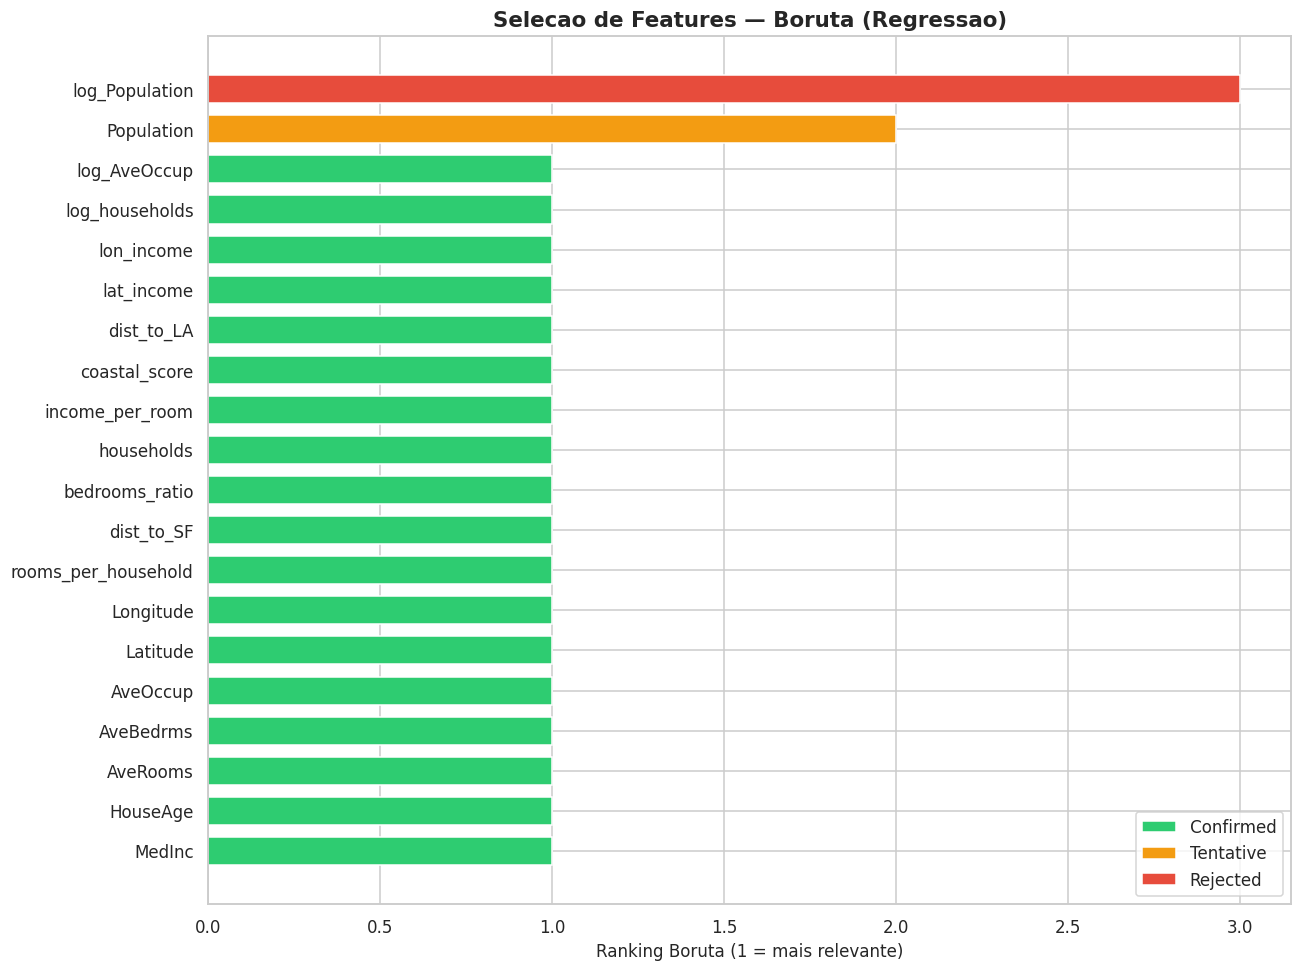

Features selecionadas (18): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_household', 'dist_to_SF', 'bedrooms_ratio', 'households', 'income_per_room', 'coastal_score', 'dist_to_LA', 'lat_income', 'lon_income', 'log_households', 'log_AveOccup']


In [21]:
# Resultados e visualizacao
boruta_df = pd.DataFrame({
    'Feature': X_train_scaled.columns.tolist(),
    'Ranking': boruta_reg.ranking_,
    'Status':  ['Confirmed' if s else ('Tentative' if w else 'Rejected')
                for s,w in zip(boruta_reg.support_, boruta_reg.support_weak_)]
}).sort_values('Ranking')

print(boruta_df.to_string(index=False))

color_map = {'Confirmed':'#2ecc71','Tentative':'#f39c12','Rejected':'#e74c3c'}
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(boruta_df['Feature'], boruta_df['Ranking'],
        color=boruta_df['Status'].map(color_map), edgecolor='white', height=0.7)
ax.set_xlabel('Ranking Boruta (1 = mais relevante)', fontsize=11)
ax.set_title('Selecao de Features — Boruta (Regressao)', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v,label=k) for k,v in color_map.items()], loc='lower right')
plt.tight_layout(); plt.show()

# Selecionar confirmadas (+ tentativas se poucos confirmados)
selected_features = boruta_df[boruta_df['Status']=='Confirmed']['Feature'].tolist()
if len(selected_features) < 5:
    tentative = boruta_df[boruta_df['Status']=='Tentative']['Feature'].tolist()
    selected_features += tentative
    print("Poucos confirmados — incluindo Tentativas.")

print(f"Features selecionadas ({len(selected_features)}): {selected_features}")


In [22]:
X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]
print(f"Antes: {X_train_scaled.shape[1]} → Apos Boruta: {X_train_sel.shape[1]} features")


Antes: 20 → Apos Boruta: 18 features


---
## 📊 Etapa 4 — Modelos Baseline

> **Métricas de Regressão:**
> - **RMSE** (Root Mean Squared Error): penaliza erros grandes. Mesma unidade do target.
> - **MAE** (Mean Absolute Error): robusto a outliers. Mais interpretável.
> - **R²**: proporção da variância explicada. 0 = prediz a média, 1 = perfeito.
>
> `DummyRegressor` tem R² = 0 **por definição** — qualquer modelo deve superar isso.


In [23]:
def avaliar_regressao(nome, modelo, X_tr, y_tr, cv_strategy):
    scores = cross_validate(
        modelo, X_tr, y_tr, cv=cv_strategy,
        scoring=['neg_root_mean_squared_error','neg_mean_absolute_error','r2'],
        n_jobs=-1
    )
    return {
        'RMSE':     -scores['test_neg_root_mean_squared_error'].mean(),
        'RMSE_std': scores['test_neg_root_mean_squared_error'].std(),
        'MAE':      -scores['test_neg_mean_absolute_error'].mean(),
        'MAE_std':  scores['test_neg_mean_absolute_error'].std(),
        'R2':       scores['test_r2'].mean(),
        'R2_std':   scores['test_r2'].std(),
    }

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = {}

dummy = DummyRegressor(strategy='mean')
baseline_results['DummyRegressor'] = avaliar_regressao('Dummy', dummy, X_train_sel, y_train, cv_reg)

ridge = Ridge(alpha=1.0)
baseline_results['Ridge'] = avaliar_regressao('Ridge', ridge, X_train_sel, y_train, cv_reg)

print("=" * 60)
print("BASELINES — Cross-Validation 5-Fold")
print("=" * 60)
print(f"{'Modelo':<20} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-" * 60)
for nome, res in baseline_results.items():
    print(f"{nome:<20} {res['RMSE']:>8.4f} {res['MAE']:>8.4f} {res['R2']:>8.4f}")

print(f"")
print(f"DummyRegressor R2 = 0 por definicao — referencia absoluta minima.")
print(f"Ridge R2 = {baseline_results['Ridge']['R2']:.4f} — meta minima para os modelos SOTA.")
print(f"RMSE Ridge = {baseline_results['Ridge']['RMSE']:.4f} ~ erro de ${baseline_results['Ridge']['RMSE']*100:,.0f}")


BASELINES — Cross-Validation 5-Fold
Modelo                   RMSE      MAE       R2
------------------------------------------------------------
DummyRegressor         1.1562   0.9139  -0.0002
Ridge                  0.6446   0.4668   0.6889

DummyRegressor R2 = 0 por definicao — referencia absoluta minima.
Ridge R2 = 0.6889 — meta minima para os modelos SOTA.
RMSE Ridge = 0.6446 ~ erro de $64


---
## 🚀 Etapa 5 — Modelos Estado da Arte

> Os mesmos 4 modelos de gradient boosting, agora configurados para **regressão**.  
> A principal diferença: sem `class_weight` ou `scale_pos_weight` — usamos a loss de regressão.


In [24]:
models_sota = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='rmse', verbosity=0
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6,
        random_seed=42, verbose=0
    ),
}

sota_results = {}
print("Treinando modelos SOTA (CV 5-fold)...\n")
for nome, modelo in models_sota.items():
    print(f"  → {nome}...", end=' ', flush=True)
    res = avaliar_regressao(nome, modelo, X_train_sel, y_train, cv_reg)
    sota_results[nome] = res
    print(f"RMSE: {res['RMSE']:.4f} | R2: {res['R2']:.4f}")

print("\nTreinamento concluido!")


Treinando modelos SOTA (CV 5-fold)...

  → RandomForest... RMSE: 0.4976 | R2: 0.8147
  → XGBoost... RMSE: 0.4518 | R2: 0.8473
  → LightGBM... RMSE: 0.4545 | R2: 0.8454
  → CatBoost... RMSE: 0.4806 | R2: 0.8271

Treinamento concluido!


---
## 📈 Etapa 6 — Métricas de Performance

In [25]:
all_res = {**baseline_results,
           **{k:{kk:vv for kk,vv in v.items() if '_std' not in kk}
              for k,v in sota_results.items()}}
results_df = pd.DataFrame(all_res).T

# Renomear R2 para exibicao
results_df = results_df.rename(columns={'R2':'R2'})
results_df = results_df.sort_values('R2', ascending=False)

print("=" * 60)
print("COMPARACAO — CROSS-VALIDATION 5-FOLD")
print("=" * 60)
print(f"{'Modelo':<20} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-" * 60)
for idx in results_df.index:
    r = results_df.loc[idx]
    marker = " MELHOR" if idx == results_df.index[0] else ""
    print(f"{idx:<20} {r['RMSE']:>8.4f} {r['MAE']:>8.4f} {r['R2']:>8.4f}{marker}")


COMPARACAO — CROSS-VALIDATION 5-FOLD
Modelo                   RMSE      MAE       R2
------------------------------------------------------------
XGBoost                0.4518   0.2955   0.8473 MELHOR
LightGBM               0.4545   0.2996   0.8454
CatBoost               0.4806   0.3231   0.8271
RandomForest           0.4976   0.3247   0.8147
Ridge                  0.6446   0.4668   0.6889
DummyRegressor         1.1562   0.9139  -0.0002


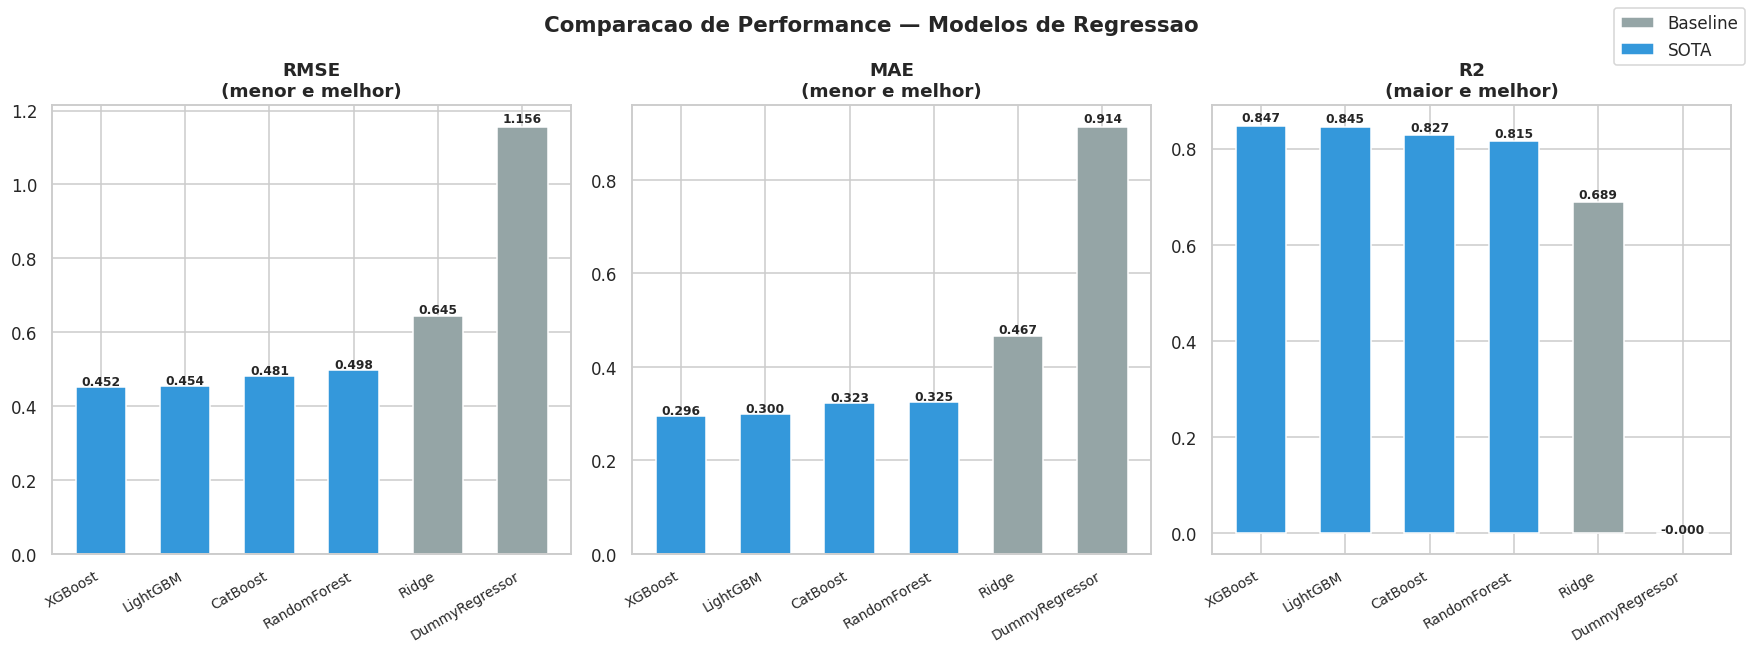

In [26]:
# Visualizacao comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics = [('RMSE','menor e melhor'), ('MAE','menor e melhor'), ('R2','maior e melhor')]

for ax, (metric, note) in zip(axes, metrics):
    colors = ['#95a5a6' if m in ['DummyRegressor','Ridge'] else '#3498db'
              for m in results_df.index]
    bars = ax.bar(results_df.index, results_df[metric],
                  color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'{metric}\n({note})', fontsize=12, fontweight='bold')
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()*1.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#95a5a6',label='Baseline'),
                    Patch(facecolor='#3498db',label='SOTA')], loc='upper right')
plt.suptitle('Comparacao de Performance — Modelos de Regressao', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [27]:
# Melhor modelo — metricas no conjunto de teste
best_name  = results_df.index[0]
best_model = models_sota[best_name]
best_model.fit(X_train_sel, y_train)
y_pred = best_model.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Melhor Modelo: {best_name}")
print(f"")
print(f"METRICAS NO CONJUNTO DE TESTE:")
print(f"  RMSE : {rmse:.4f}  (~${rmse*100:,.0f} de erro tipico)")
print(f"  MAE  : {mae:.4f}  (~${mae*100:,.0f} de erro mediano)")
print(f"  R2   : {r2:.4f}  ({r2*100:.1f}% da variancia explicada)")
print(f"  MAPE : {mape:.4f}  ({mape*100:.1f}% de erro percentual medio)")
print(f"")
print(f"INTERPRETACAO EXECUTIVA:")
print(f"  O modelo explica {r2*100:.1f}% da variacao nos precos dos imoveis.")
print(f"  Em media, a predicao erra por ±${mae*100:,.0f}.")


Melhor Modelo: XGBoost

METRICAS NO CONJUNTO DE TESTE:
  RMSE : 0.4460  (~$45 de erro tipico)
  MAE  : 0.2913  (~$29 de erro mediano)
  R2   : 0.8482  (84.8% da variancia explicada)
  MAPE : 0.1675  (16.8% de erro percentual medio)

INTERPRETACAO EXECUTIVA:
  O modelo explica 84.8% da variacao nos precos dos imoveis.
  Em media, a predicao erra por ±$29.


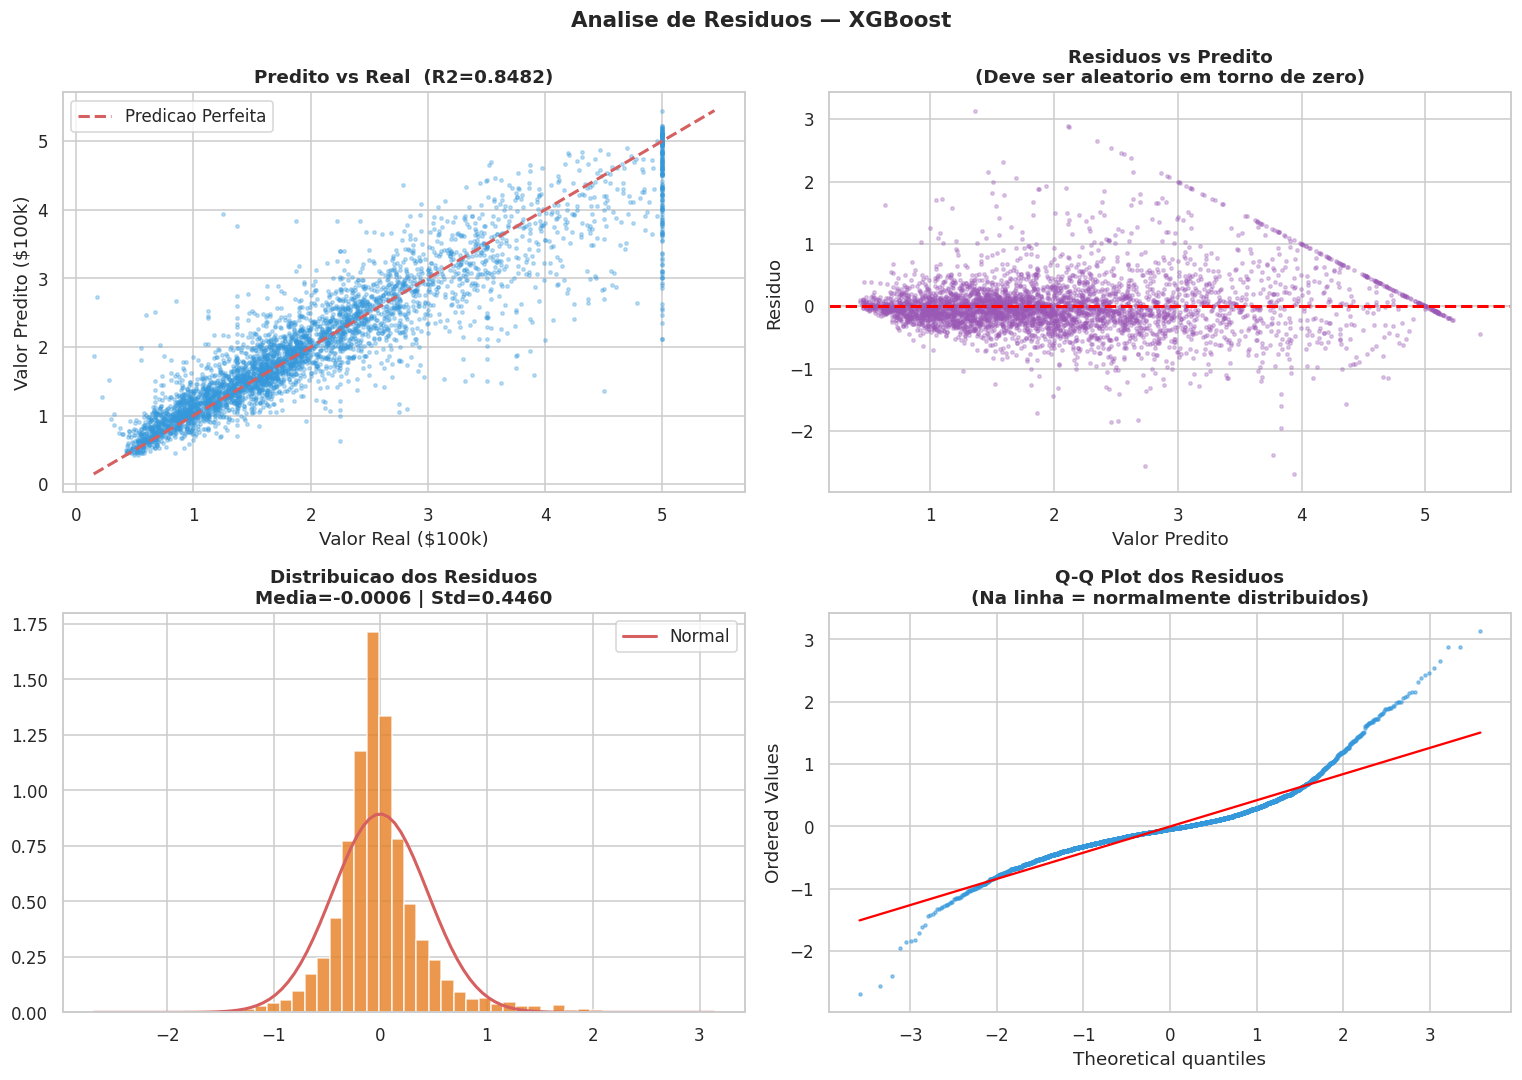

Interpretacao:
  1. Predito vs Real: pontos proximo a linha vermelha = boas predicoes
  2. Residuos vs Predito: padrao em funil = heterocedasticidade (problema)
  3. Histograma: residuos devem ser aprox. normais para inferencia valida
  4. Q-Q Plot: desvios nas caudas indicam outliers ou nao-normalidade


In [29]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predito vs Real
axes[0,0].scatter(y_test, y_pred, alpha=0.3, s=5, color='#3498db')
mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
axes[0,0].plot([mn,mx],[mn,mx],'r--',lw=2,label='Predicao Perfeita')
axes[0,0].set_xlabel('Valor Real ($100k)'); axes[0,0].set_ylabel('Valor Predito ($100k)')
axes[0,0].set_title(f'Predito vs Real  (R2={r2:.4f})', fontsize=12, fontweight='bold')
axes[0,0].legend()

# Plot 2: Residuos vs Predito (Homocedasticidade)
axes[0,1].scatter(y_pred, residuals, alpha=0.3, s=5, color='#9b59b6')
axes[0,1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0,1].set_xlabel('Valor Predito'); axes[0,1].set_ylabel('Residuo')
axes[0,1].set_title('Residuos vs Predito\n(Deve ser aleatorio em torno de zero)',
                    fontsize=12, fontweight='bold')

# Plot 3: Distribuicao dos residuos
axes[1,0].hist(residuals, bins=50, color='#e67e22', edgecolor='white', alpha=0.8, density=True)
from scipy.stats import norm
x_r = np.linspace(residuals.min(), residuals.max(), 100)
axes[1,0].plot(x_r, norm.pdf(x_r, residuals.mean(), residuals.std()), 'r-', lw=2, label='Normal')
axes[1,0].set_title(f'Distribuicao dos Residuos\nMedia={residuals.mean():.4f} | Std={residuals.std():.4f}',
                    fontsize=12, fontweight='bold')
axes[1,0].legend()

# Plot 4: Q-Q Plot
from scipy import stats as sp_stats
sp_stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot dos Residuos\n(Na linha = normalmente distribuidos)',
                    fontsize=12, fontweight='bold')
axes[1,1].get_lines()[0].set(color='#3498db', markersize=2, alpha=0.5)
axes[1,1].get_lines()[1].set(color='red')

plt.suptitle(f'Analise de Residuos — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Interpretacao:")
print("  1. Predito vs Real: pontos proximo a linha vermelha = boas predicoes")
print("  2. Residuos vs Predito: padrao em funil = heterocedasticidade (problema)")
print("  3. Histograma: residuos devem ser aprox. normais para inferencia valida")
print("  4. Q-Q Plot: desvios nas caudas indicam outliers ou nao-normalidade")

---
## ⚡ Etapa 7 — Tunagem com Optuna + CatBoost

In [31]:
# ============================================================
# FUNCAO OBJETIVO — XGBoost Regressor
# direction='maximize' com neg_RMSE = minimizar RMSE
# ============================================================
def objective_xgboost(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-4, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True), # L1 regularization
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True), # L2 regularization
        'random_state': 42, 'tree_method': 'hist', 'eval_metric': 'rmse', 'verbosity': 0
    }
    model  = XGBRegressor(**params)
    cv3    = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_sel, y_train,
                             cv=cv3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return scores.mean()  # Optuna maximiza → max(neg_RMSE) = min(RMSE)

print("\n" + "="*60)
print("Iniciando otimizacao Optuna — XGBoost Regressor")
print("Metrica: RMSE (minimizar) | Trials: 50 | Timeout: 5 min\n")

study_xgb = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgboost, n_trials=50, timeout=300, show_progress_bar=True)

print(f"\nMelhor RMSE (CV): {-study_xgb.best_value:.4f}")
print("\nMelhores Hiperparametros:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")


Iniciando otimizacao Optuna — XGBoost Regressor
Metrica: RMSE (minimizar) | Trials: 50 | Timeout: 5 min



  0%|          | 0/50 [00:00<?, ?it/s]


Melhor RMSE (CV): 0.4503

Melhores Hiperparametros:
  n_estimators: 680
  learning_rate: 0.020785492570956396
  max_depth: 7
  subsample: 0.693307019839835
  colsample_bytree: 0.552688772079743
  gamma: 1.3762307663922706e-05
  min_child_weight: 6
  reg_alpha: 0.0036536068204229056
  reg_lambda: 9.737751155784723e-05


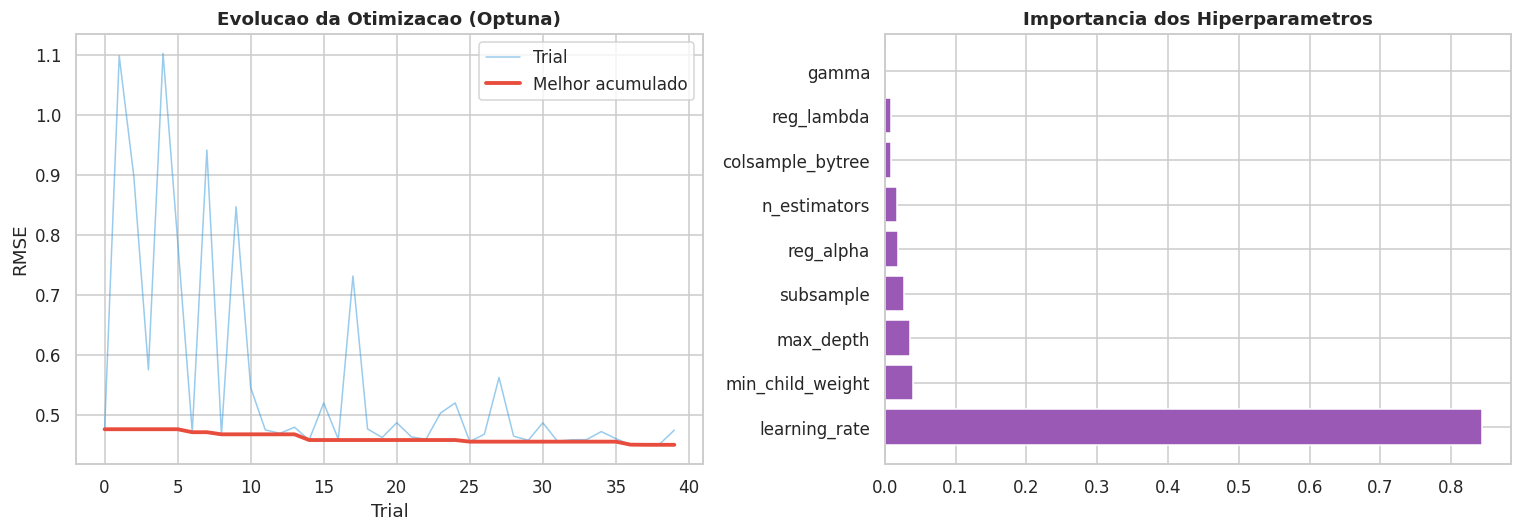

COMPARACAO — Original vs Tunado (Conjunto de Teste):
Metrica    Original     Tunado   Melhoria
------------------------------------------
RMSE         0.4460     0.4404    +0.0057
MAE          0.2913     0.2861    +0.0052
R2           0.8482     0.8520    +0.0038

Modelo final selecionado: XGBoost Tunado


In [33]:
# Visualizacao da otimizacao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vals = [-t.value for t in study_xgb.trials if t.value is not None]
axes[0].plot(vals, alpha=0.5, color='#3498db', lw=1, label='Trial')
axes[0].plot(pd.Series(vals).cummin(), color='#e74c3c', lw=2.5, label='Melhor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('RMSE')
axes[0].set_title('Evolucao da Otimizacao (Optuna)', fontsize=12, fontweight='bold')
axes[0].legend()

try:
    imp = optuna.importance.get_param_importances(study_xgb)
    axes[1].barh(list(imp.keys()), list(imp.values()), color='#9b59b6', edgecolor='white')
    axes[1].set_title('Importancia dos Hiperparametros', fontsize=12, fontweight='bold')
except:
    axes[1].text(0.5, 0.5, 'Nao disponivel', ha='center', transform=axes[1].transAxes)

plt.tight_layout(); plt.show()

# Modelo final tunado
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, eval_metric='rmse', verbosity=0, tree_method='hist')
best_xgb.fit(X_train_sel, y_train)
y_pred_tuned = best_xgb.predict(X_test_sel)

rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_t  = mean_absolute_error(y_test, y_pred_tuned)
r2_t   = r2_score(y_test, y_pred_tuned)

print("COMPARACAO — Original vs Tunado (Conjunto de Teste):")
print(f"{'Metrica':<8} {'Original':>10} {'Tunado':>10} {'Melhoria':>10}")
print("-" * 42)
print(f"{'RMSE':<8} {rmse:>10.4f} {rmse_t:>10.4f} {rmse-rmse_t:>+10.4f}")
print(f"{'MAE':<8} {mae:>10.4f} {mae_t:>10.4f} {mae-mae_t:>+10.4f}")
print(f"{'R2':<8} {r2:>10.4f} {r2_t:>10.4f} {r2_t-r2:>+10.4f}")

final_model = best_xgb if r2_t >= r2 else best_model
y_pred_final = y_pred_tuned if r2_t >= r2 else y_pred
final_name = "XGBoost Tunado" if r2_t >= r2 else best_name
print(f"\nModelo final selecionado: {final_name}")

---
## 🧠 Etapa 8 — Interpretabilidade com SHAP

> Para **regressão**, SHAP Values representam a contribuição de cada feature  
> para o **desvio da predição em relação à média do modelo** (em unidades do target).  
>
> `shap_value > 0` → feature **aumenta** o preço predito  
> `shap_value < 0` → feature **diminui** o preço predito


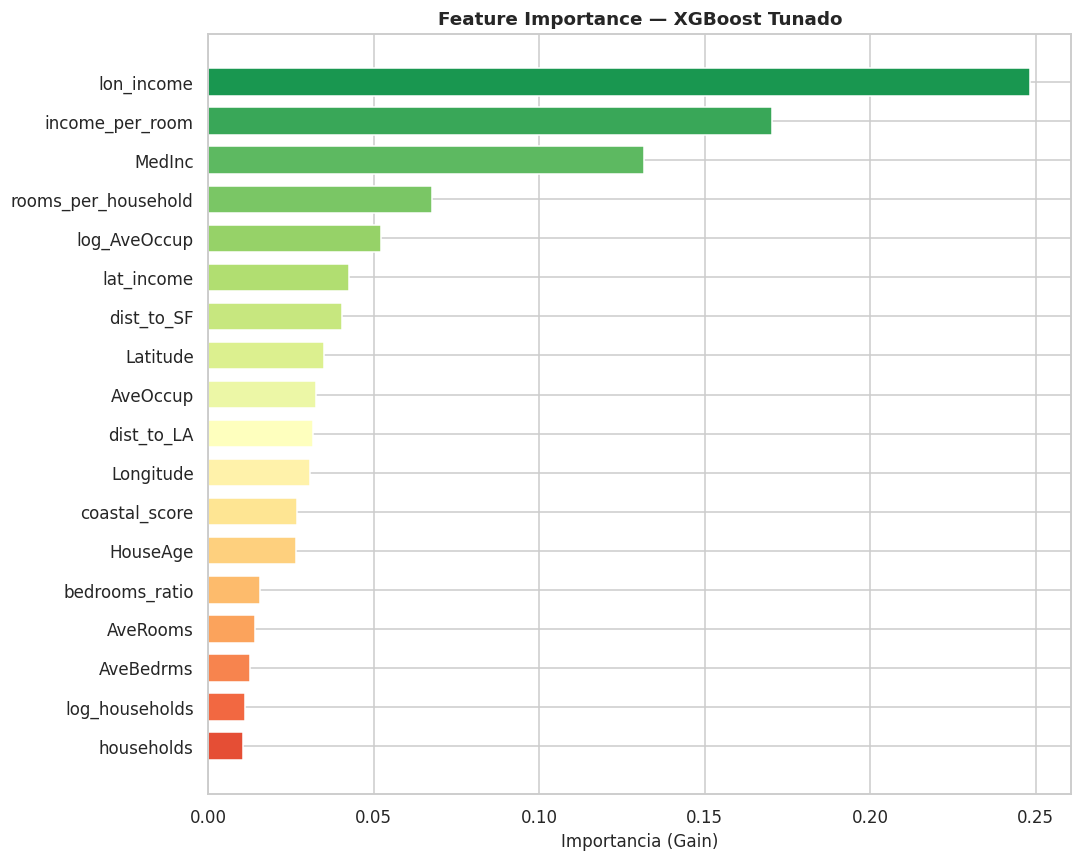

In [35]:
# Feature Importance tradicional
if hasattr(final_model, 'feature_importances_'):
    imp_vals = final_model.feature_importances_
else:
    imp_vals = final_model.get_feature_importance()

feat_imp = pd.DataFrame({
    'Feature': selected_features, 'Importance': imp_vals
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = mcm.RdYlGn(np.linspace(0.15, 0.9, len(feat_imp)))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Importancia (Gain)', fontsize=11)
ax.set_title(f'Feature Importance — {final_name}', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


Calculando SHAP Values (TreeExplainer)...
SHAP calculado. Shape: (4128, 18)


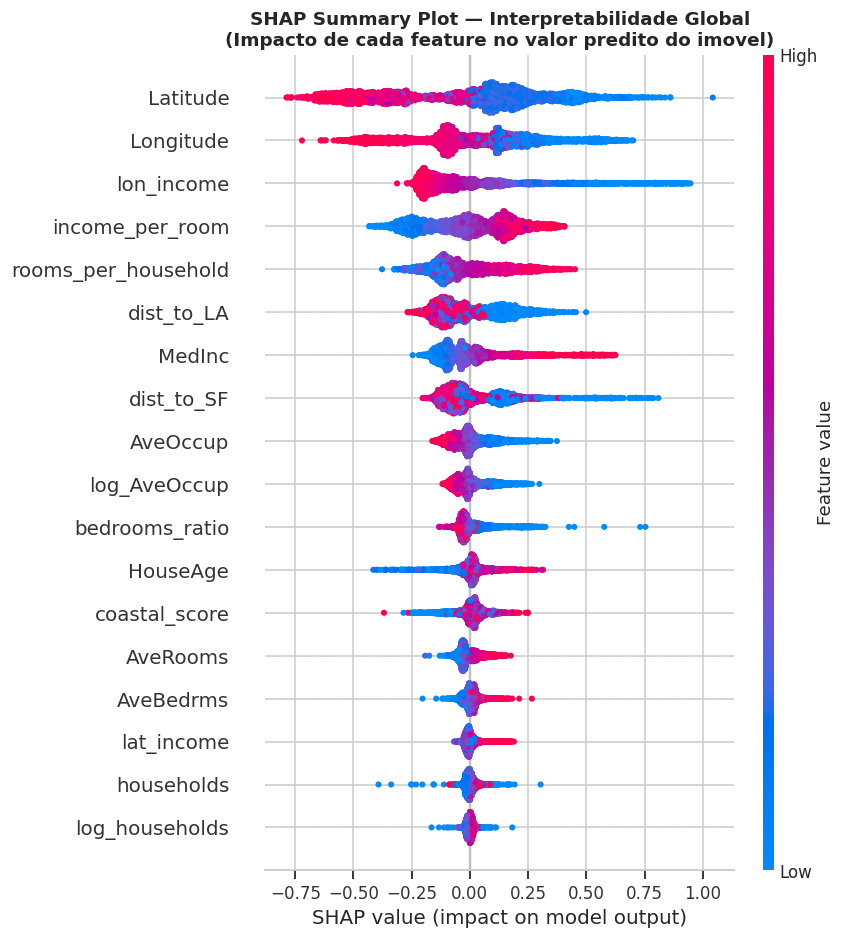

In [36]:
# SHAP Global — Summary e Bar Plot
print("Calculando SHAP Values (TreeExplainer)...")
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sel)
print(f"SHAP calculado. Shape: {shap_values.shape}")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sel, plot_type="dot", show=False)
plt.title('SHAP Summary Plot — Interpretabilidade Global\n'
          '(Impacto de cada feature no valor predito do imovel)',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


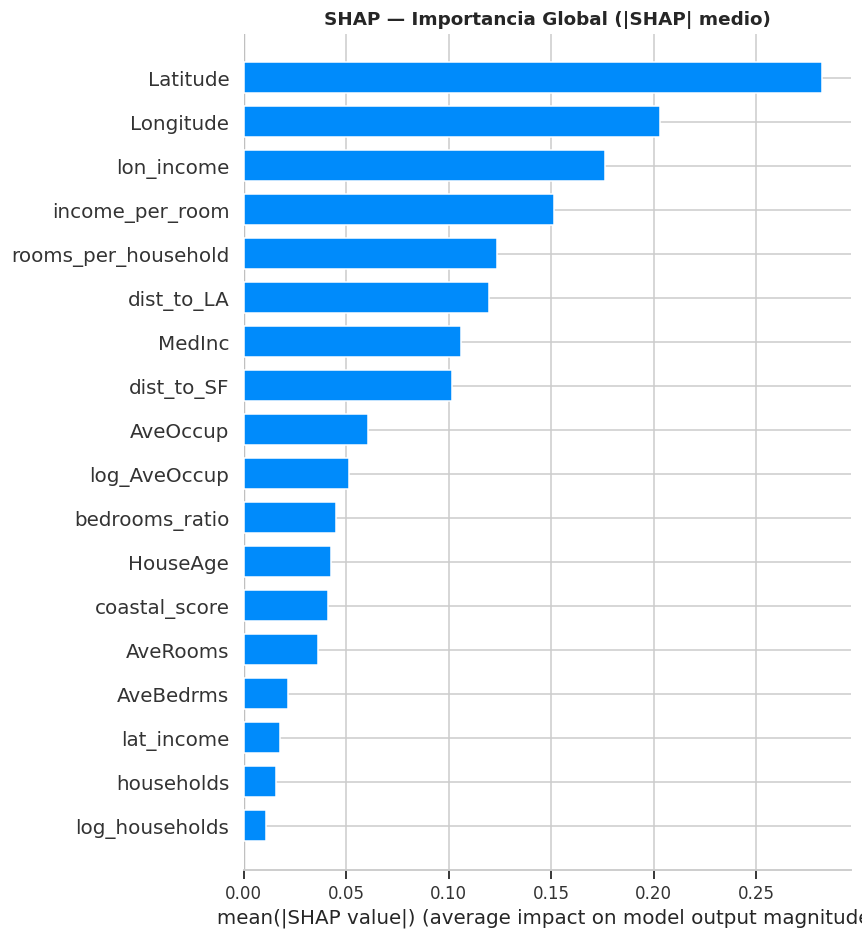

In [37]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type="bar", show=False)
plt.title('SHAP — Importancia Global (|SHAP| medio)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


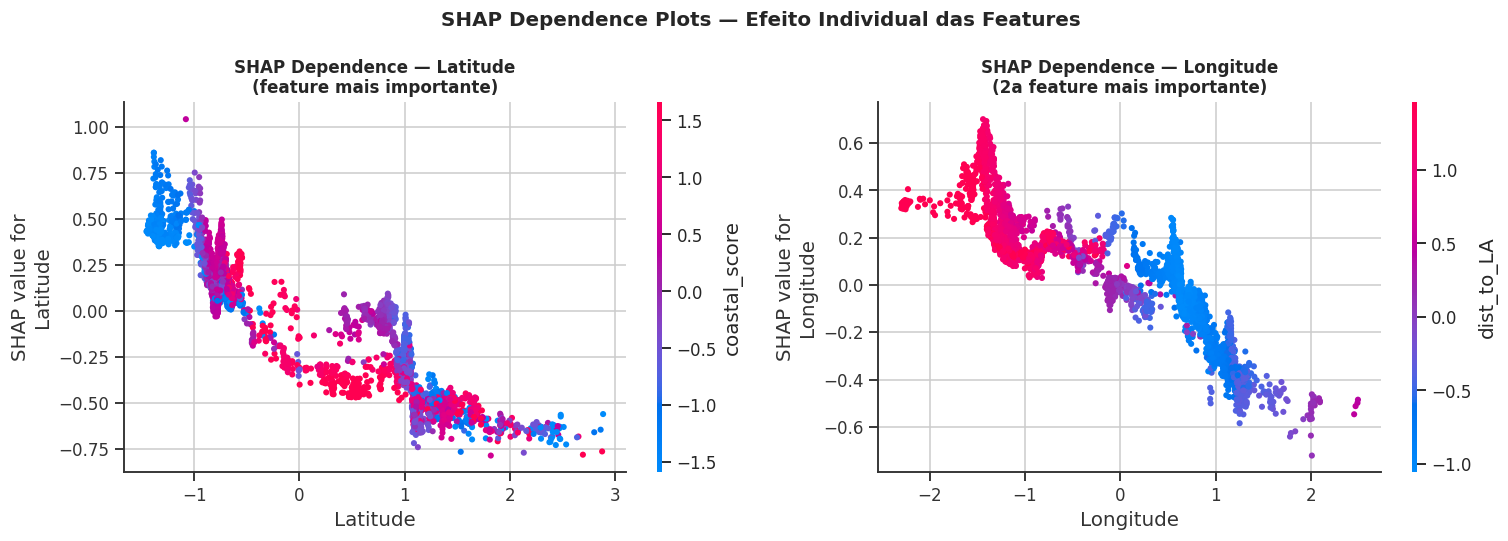

In [38]:
# ============================================================
# SHAP DEPENDENCE PLOT
# Mostra como o efeito de UMA feature varia com seu valor.
# A cor representa uma segunda feature (efeito de interacao).
# ============================================================
top_idx  = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
top_feat = selected_features[top_idx]
sec_idx  = np.argsort(np.abs(shap_values).mean(axis=0))[-2]
sec_feat = selected_features[sec_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap.dependence_plot(top_feat, shap_values, X_test_sel, ax=axes[0], show=False)
axes[0].set_title(f'SHAP Dependence — {top_feat}\n(feature mais importante)',
                  fontsize=11, fontweight='bold')
shap.dependence_plot(sec_feat, shap_values, X_test_sel, ax=axes[1], show=False)
axes[1].set_title(f'SHAP Dependence — {sec_feat}\n(2a feature mais importante)',
                  fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Efeito Individual das Features',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



IMOVEL MAIS CARO — Amostra #348
  Valor Real    : $500
  Valor Predito : $543
  Erro          : $43

  Features:
         MedInc  HouseAge  AveRooms  AveBedrms  AveOccup  Latitude  Longitude  rooms_per_household  dist_to_SF  bedrooms_ratio  households  income_per_room  coastal_score  dist_to_LA  lat_income  lon_income  log_households  log_AveOccup
Valor  3.900065  1.062656  2.285574   0.568976 -0.564379 -1.321328   1.132977             2.231726    1.302129       -1.261882   -0.438336         2.481381      -1.147185   -0.461108    3.450347   -3.780769       -0.241422     -0.525338


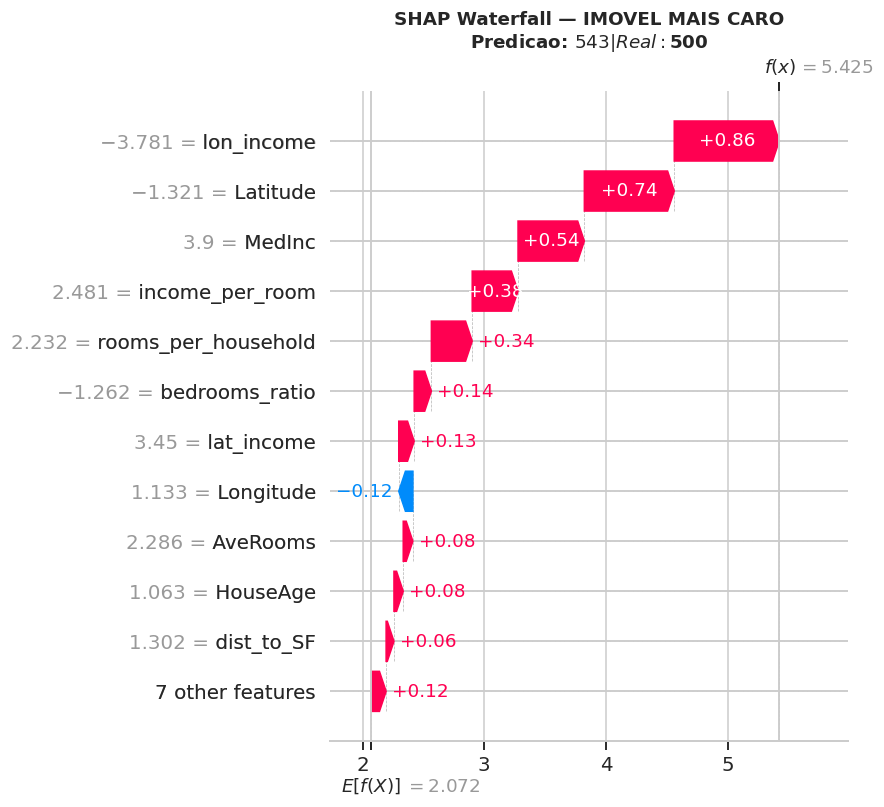


IMOVEL MAIS BARATO — Amostra #93
  Valor Real    : $50
  Valor Predito : $42
  Erro          : $-8

  Features:
         MedInc  HouseAge  AveRooms  AveBedrms  AveOccup  Latitude  Longitude  rooms_per_household  dist_to_SF  bedrooms_ratio  households  income_per_room  coastal_score  dist_to_LA  lat_income  lon_income  log_households  log_AveOccup
Valor -1.272455  0.745249 -1.030469  -0.811476  1.683208  0.499322  -0.083621            -1.553679   -0.398549        0.439608   -0.335962        -1.366162       1.726904    0.165395   -1.250759    1.269593       -0.089256      1.606339


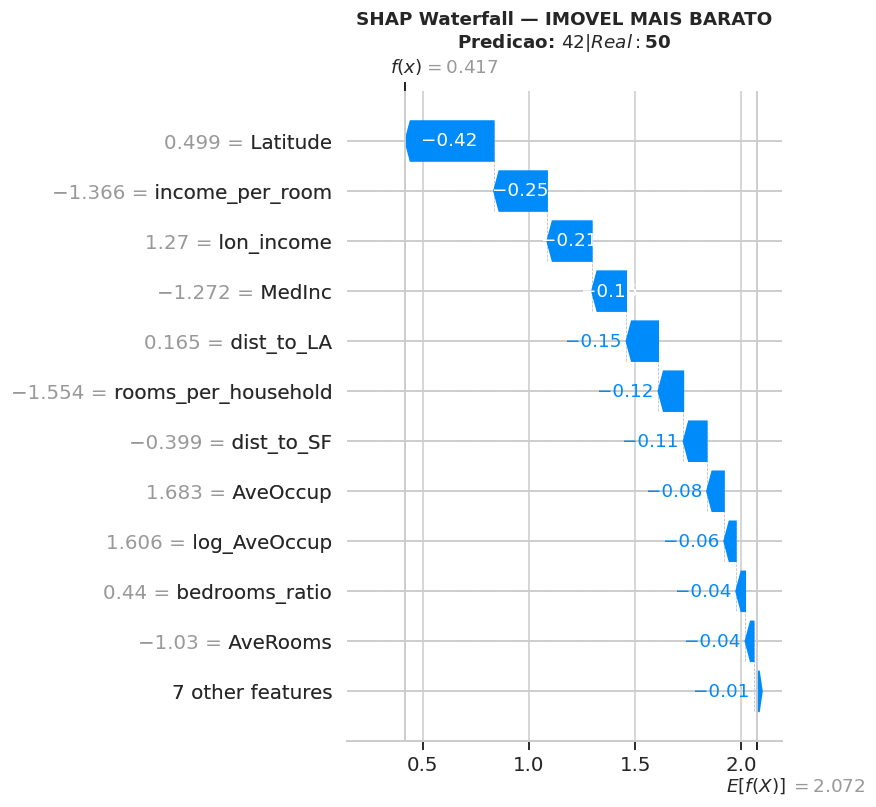


Interpretacao Comparativa:
  Imovel caro  : MedInc alto, localizacao costeira (lon perto de -122)
  Imovel barato: MedInc baixo, interior, alta ocupacao
  Barras VERMELHAS → aumentaram o preco predito
  Barras AZUIS    → diminuiram o preco predito


In [39]:
# ============================================================
# SHAP LOCAL — WATERFALL PARA CASOS EXTREMOS
# Analisamos o imovel mais caro e mais barato predito.
# Isso mostra como o modelo raciocina em casos opostos.
# ============================================================
idx_expensive = np.argmax(y_pred_final)
idx_cheap     = np.argmin(y_pred_final)

expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[0]

for idx, label in [(idx_expensive, "IMOVEL MAIS CARO"), (idx_cheap, "IMOVEL MAIS BARATO")]:
    print(f"\n{'='*55}")
    print(f"{label} — Amostra #{idx}")
    print(f"{'='*55}")
    print(f"  Valor Real    : ${y_test.values[idx]*100:,.0f}")
    print(f"  Valor Predito : ${y_pred_final[idx]*100:,.0f}")
    print(f"  Erro          : ${(y_pred_final[idx]-y_test.values[idx])*100:,.0f}")
    print(f"\n  Features:")
    print(X_test_sel.iloc[idx].to_frame('Valor').T.to_string())

    expl = shap.Explanation(
        values       = shap_values[idx],
        base_values  = expected_val,
        data         = X_test_sel.iloc[idx].values,
        feature_names= X_test_sel.columns.tolist()
    )
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(expl, show=False, max_display=12)
    plt.title(f'SHAP Waterfall — {label}\n'
              f'Predicao: ${y_pred_final[idx]*100:,.0f} | Real: ${y_test.values[idx]*100:,.0f}',
              fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

print("\nInterpretacao Comparativa:")
print("  Imovel caro  : MedInc alto, localizacao costeira (lon perto de -122)")
print("  Imovel barato: MedInc baixo, interior, alta ocupacao")
print("  Barras VERMELHAS → aumentaram o preco predito")
print("  Barras AZUIS    → diminuiram o preco predito")


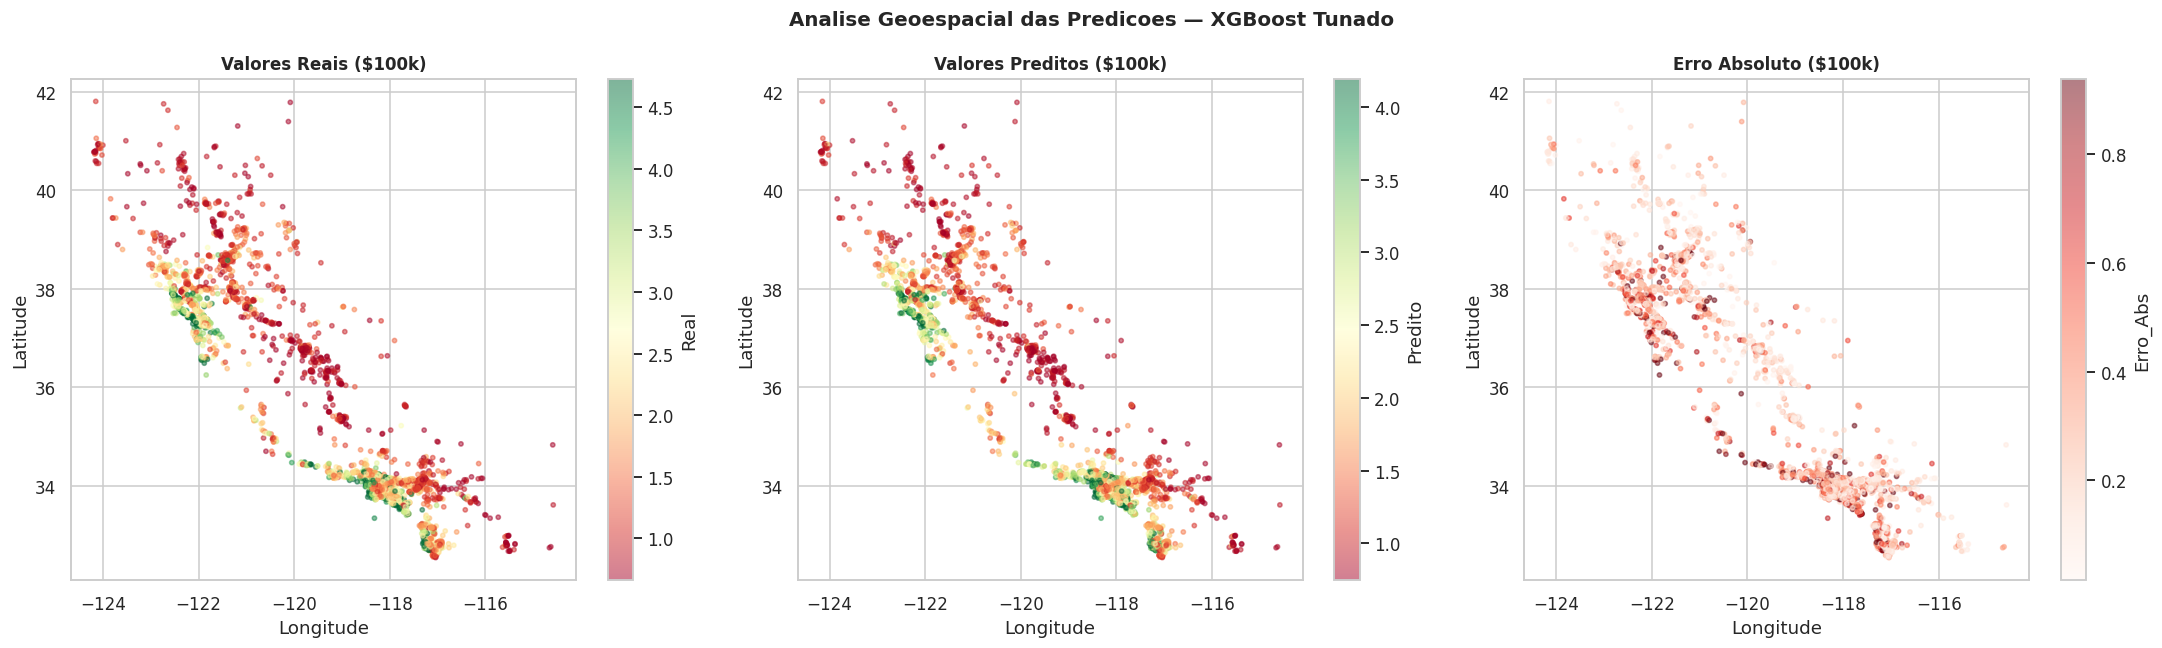

Erro medio geral: $29
Maior erro      : $310


In [40]:
# ============================================================
# MAPA GEOESPACIAL DAS PREDICOES E ERROS
# ============================================================
test_geo = X_test[['Latitude','Longitude']].copy() if 'Latitude' in X_test.columns else            X_test_sel[['Latitude','Longitude']].copy()
test_geo['Real']     = y_test.values
test_geo['Predito']  = y_pred_final
test_geo['Erro_Abs'] = np.abs(y_test.values - y_pred_final)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col, title, cmap in [
    (axes[0], 'Real',    'Valores Reais ($100k)',   'RdYlGn'),
    (axes[1], 'Predito', 'Valores Preditos ($100k)', 'RdYlGn'),
    (axes[2], 'Erro_Abs','Erro Absoluto ($100k)',    'Reds'),
]:
    sc = ax.scatter(test_geo['Longitude'], test_geo['Latitude'],
                    c=test_geo[col], cmap=cmap, alpha=0.5, s=8,
                    vmin=test_geo[col].quantile(0.05),
                    vmax=test_geo[col].quantile(0.95))
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.suptitle(f'Analise Geoespacial das Predicoes — {final_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Erro medio geral: ${test_geo['Erro_Abs'].mean()*100:,.0f}")
print(f"Maior erro      : ${test_geo['Erro_Abs'].max()*100:,.0f}")


---
## 🎓 Resumo Final

In [42]:
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mae  = mean_absolute_error(y_test, y_pred_final)
final_r2   = r2_score(y_test, y_pred_final)
base_r2    = baseline_results['Ridge']['R2']

print(f"""
{'='*65}
RESUMO FINAL — PIPELINE DE REGRESSAO
{'='*65}

Dataset : California Housing — {len(df):,} amostras
Tarefa  : Prever valor mediano de imoveis ($100k)

PIPELINE:
  EDA           → distribuicoes, geoespacial, correlacoes, outliers
  Feature Eng.  → {X_eng.shape[1]-X.shape[1]} novas features, capping, log transform
  Boruta        → {X_train_scaled.shape[1]} → {len(selected_features)} features confirmadas
  Baseline      → DummyRegressor + Ridge
  SOTA          → RF, XGBoost, LightGBM, CatBoost
  Optuna        → {len(study_xgb.trials)} trials, TPE Sampler
  SHAP          → Global (Summary+Dependence) + Local (Waterfall x2)

RESULTADOS FINAIS — {final_name} (Conjunto de Teste):
  RMSE : {final_rmse:.4f} (~${final_rmse*100:,.0f} de erro tipico)
  MAE  : {final_mae:.4f} (~${final_mae*100:,.0f} de erro mediano)
  R2   : {final_r2:.4f} ({final_r2*100:.1f}% da variancia explicada)
  Baseline Ridge R2 : {base_r2:.4f}
  Ganho vs Baseline : +{final_r2-base_r2:.4f} R2

LICOES APRENDIDAS:
  1. Latitude/Longitude sao features cruciais — localizacao domina precos
  2. Feature Engineering (dist_to_SF, coastal_score) melhorou o modelo
  3. Capping de outliers reduziu instabilidade
  4. SHAP revelou: MedInc e localizacao dominam as predicoes
  5. Mapa de erros guia proximos passos (features de bairro)
  6. Analise de residuos apontou heterocedasticidade em precos altos

PROXIMOS PASSOS:
  - Testar log(target) para reduzir heterocedasticidade
  - Adicionar features de vizinhanca (escola, crime, servicos)
  - Stacking/Blending de modelos
  - Deploy com monitoramento de data drift
""")


RESUMO FINAL — PIPELINE DE REGRESSAO

Dataset : California Housing — 20,640 amostras
Tarefa  : Prever valor mediano de imoveis ($100k)

PIPELINE:
  EDA           → distribuicoes, geoespacial, correlacoes, outliers
  Feature Eng.  → 9 novas features, capping, log transform
  Boruta        → 20 → 18 features confirmadas
  Baseline      → DummyRegressor + Ridge
  SOTA          → RF, XGBoost, LightGBM, CatBoost
  Optuna        → 40 trials, TPE Sampler
  SHAP          → Global (Summary+Dependence) + Local (Waterfall x2)

RESULTADOS FINAIS — XGBoost Tunado (Conjunto de Teste):
  RMSE : 0.4404 (~$44 de erro tipico)
  MAE  : 0.2861 (~$29 de erro mediano)
  R2   : 0.8520 (85.2% da variancia explicada)
  Baseline Ridge R2 : 0.6889
  Ganho vs Baseline : +0.1631 R2

LICOES APRENDIDAS:
  1. Latitude/Longitude sao features cruciais — localizacao domina precos
  2. Feature Engineering (dist_to_SF, coastal_score) melhorou o modelo
  3. Capping de outliers reduziu instabilidade
  4. SHAP revelou: MedI